In [ ]:
from methylseqnet.predict import Predictor
from methylseqnet_repro.paths import model_checkpoints, genomes, methylation_atlas, atac_atlas, cage_atlas, annotations
from methylseqnet.annotations import fetch_tss_from_gtf

from matplotlib import pyplot as plt
import pysam

In [2]:
model_folder = model_checkpoints / "slurm32260895task0" / "checkpoints"
best_ckpt = max(
    model_folder.glob('best*.ckpt'),
    key=lambda p: p.stat().st_mtime
)
seq_only_model_folder = model_checkpoints / "slurm32260895task1" / "checkpoints"
seq_only_best_ckpt = max(
    seq_only_model_folder.glob('best*.ckpt'),
    key=lambda p: p.stat().st_mtime
)
conditioned_predictor = Predictor(best_ckpt,supplemental_outputs={"true_conditioning_state_rep","imputed_conditioning_state_rep","sequence","conditioning_state"})
unconditioned_predictor = Predictor(seq_only_best_ckpt,supplemental_outputs={"true_conditioning_state_rep","imputed_conditioning_state_rep","sequence","conditioning_state"})
io_mappings_df = conditioned_predictor.model.get_io_mappings_df()
gtf_annotation = annotations / "gencode.v49.basic.annotation.sorted.gtf.gz"

/clusterfs/nilah/oberon/environments/methylseqnet/lib/python3.11/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.5.0.post0, which is newer than your current Lightning version: v2.4.0


In [3]:
print(io_mappings_df[io_mappings_df["methylation_files"].str.contains("Oligodendrocyte")])
print(io_mappings_df[io_mappings_df["methylation_files"].str.contains("Blood-B")])

   dataset_key  absolute_channel  absolute_cell_type  channel  cell_type  \
48       atlas                48                  30       48         30   

   data_type                                   genome     methylation_files  \
48  ATAC-seq  /mnt/faststorage/oberon/genomes/hg38.fa  ['Oligodendrocytes']   

            label_files  
48  ['Oligodendrocyte']  
   dataset_key  absolute_channel  absolute_cell_type  channel  cell_type  \
10       atlas                10                   7       10          7   
11       atlas                11                   8       11          8   

   data_type                                   genome methylation_files  \
10  CAGE-seq  /mnt/faststorage/oberon/genomes/hg38.fa       ['Blood-B']   
11  ATAC-seq  /mnt/faststorage/oberon/genomes/hg38.fa   ['Blood-B-Mem']   

                                label_files  
10  ['CNhs12343', 'CNhs12352', 'CNhs12354']  
11                             ['Memory B']  


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


def add_gene_annotations(ax, transcripts, y_center=-0.5, row_height=0.3, 
                         fontsize=7, color='#2c3e50', arrow_lw=1.5,
                         block_width_frac=0.008, xlim=None):
    """
    Add gene annotations with directional arrows and labels below a genome track.
    
    Parameters
    ----------
    ax : matplotlib Axes
        The axes to draw on (typically shares x-axis with your profile plot).
    transcripts : list of dict
        Each dict has 'tss', 'threeprime', and 'gene_name'.
    y_center : float
        Vertical center for the first row of genes.
    row_height : float
        Vertical spacing between stacked genes (if overlapping).
    fontsize : int
        Font size for gene labels.
    color : str
        Base color for arrows/blocks.
    arrow_lw : float
        Line width for the transcript arrow body.
    block_width_frac : float
        Width of TSS/3' blocks as a fraction of the x-axis range.
    xlim : tuple or None
        (xmin, xmax) to use for scaling. If None, pulled from ax.get_xlim().
    """
    if xlim is None:
        xlim = ax.get_xlim()
    span = xlim[1] - xlim[0]
    block_w = span * block_width_frac

    # Sort by start coordinate for overlap detection
    sorted_tx = sorted(transcripts, key=lambda t: min(t['tss'], t['threeprime']))

    # Simple greedy row packing to avoid label collisions
    row_ends = []  # track the rightmost extent in each row
    row_assignments = []
    for tx in sorted_tx:
        left = min(tx['tss'], tx['threeprime'])
        right = max(tx['tss'], tx['threeprime'])
        placed = False
        for i, rend in enumerate(row_ends):
            if left > rend + span * 0.02:  # small gap buffer
                row_ends[i] = right
                row_assignments.append(i)
                placed = True
                break
        if not placed:
            row_assignments.append(len(row_ends))
            row_ends.append(right)

    for tx, row in zip(sorted_tx, row_assignments):
        tss = tx['tss']
        tpe = tx['threeprime']
        name = tx['gene_name']
        y = y_center - row * row_height
        forward = tpe > tss  # transcription direction

        # Draw the arrow body (TSS -> 3')
        ax.annotate(
            '', xy=(tpe, y), xytext=(tss, y),
            arrowprops=dict(
                arrowstyle='->', lw=arrow_lw, color=color,
                mutation_scale=10,
            ),
        )

        # Block at TSS (taller, filled)
        tss_rect = mpatches.FancyBboxPatch(
            (tss - block_w / 2, y - row_height * 0.4),
            block_w, row_height * 0.8,
            boxstyle="round,pad=0.0",
            facecolor=color, edgecolor='none', zorder=3,
        )
        ax.add_patch(tss_rect)

        # Block at 3' end (smaller, open)
        tpe_rect = mpatches.FancyBboxPatch(
            (tpe - block_w / 2, y - row_height * 0.3),
            block_w, row_height * 0.6,
            boxstyle="round,pad=0.0",
            facecolor='white', edgecolor=color, linewidth=1, zorder=3,
        )
        ax.add_patch(tpe_rect)

        # Gene name label, positioned above the midpoint
        mid = (tss + tpe) / 2
        ha = 'center'
        ax.text(mid, y + row_height * 0.45, name,
                fontsize=fontsize, fontstyle='italic', color=color,
                ha=ha, va='bottom', clip_on=True)

    # Clean up the annotation axes
    ax.set_xlim(xlim)
    ymin = y_center - len(row_ends) * row_height
    ax.set_ylim(ymin - row_height * 0.5, y_center + row_height)
    ax.axis('off')


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


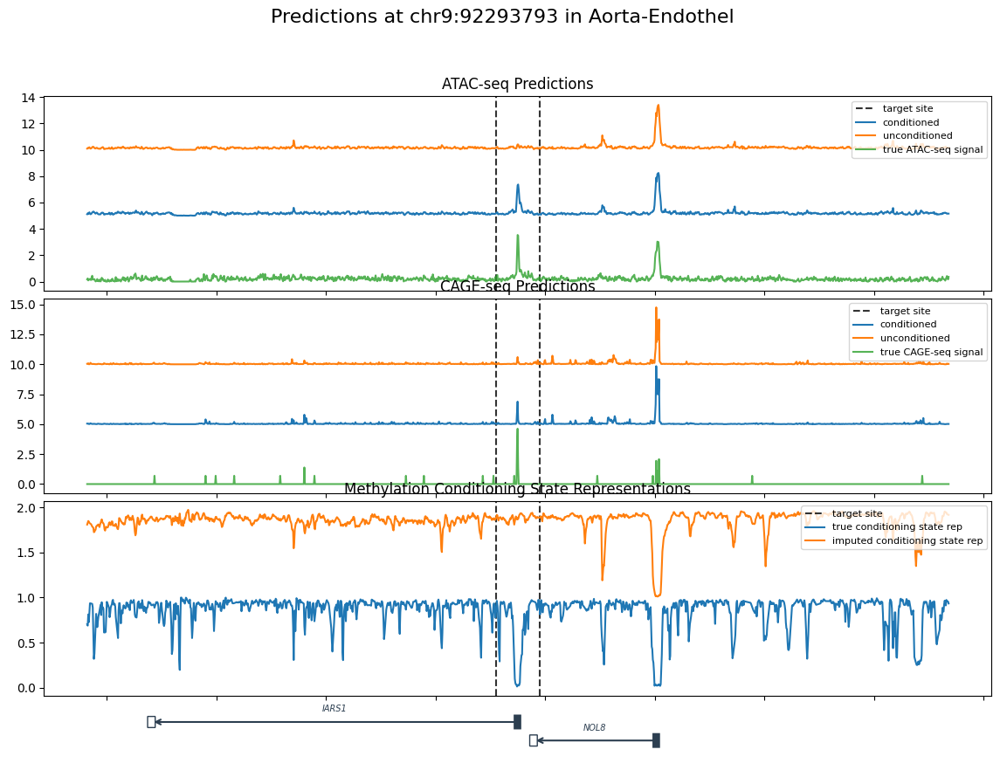

/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


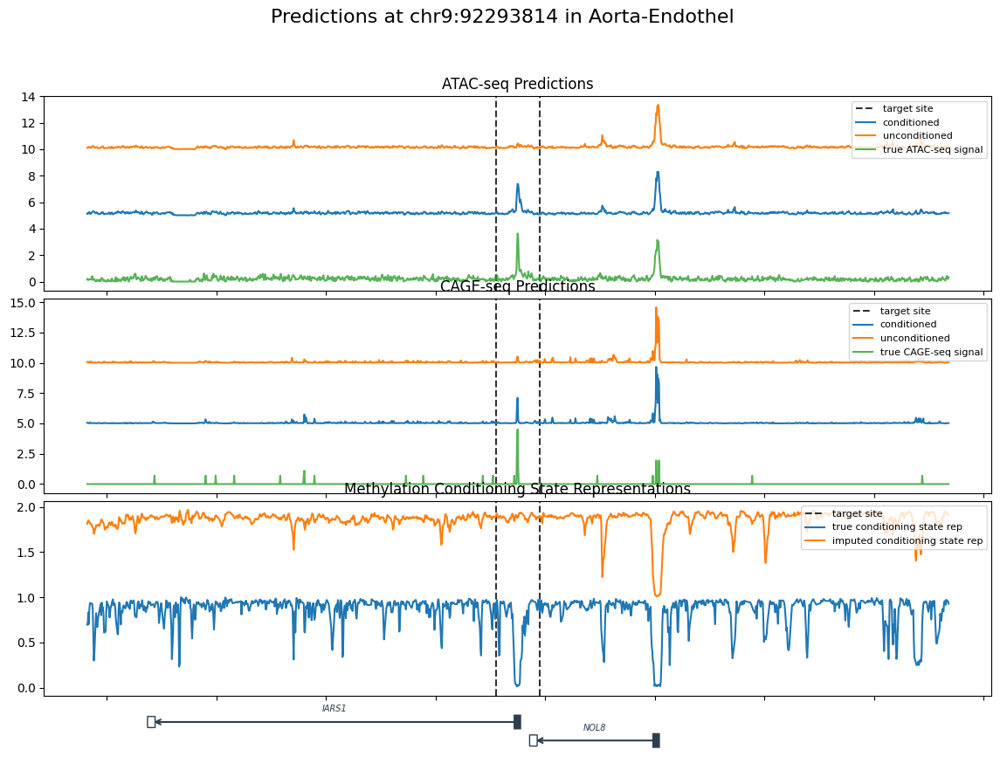

/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


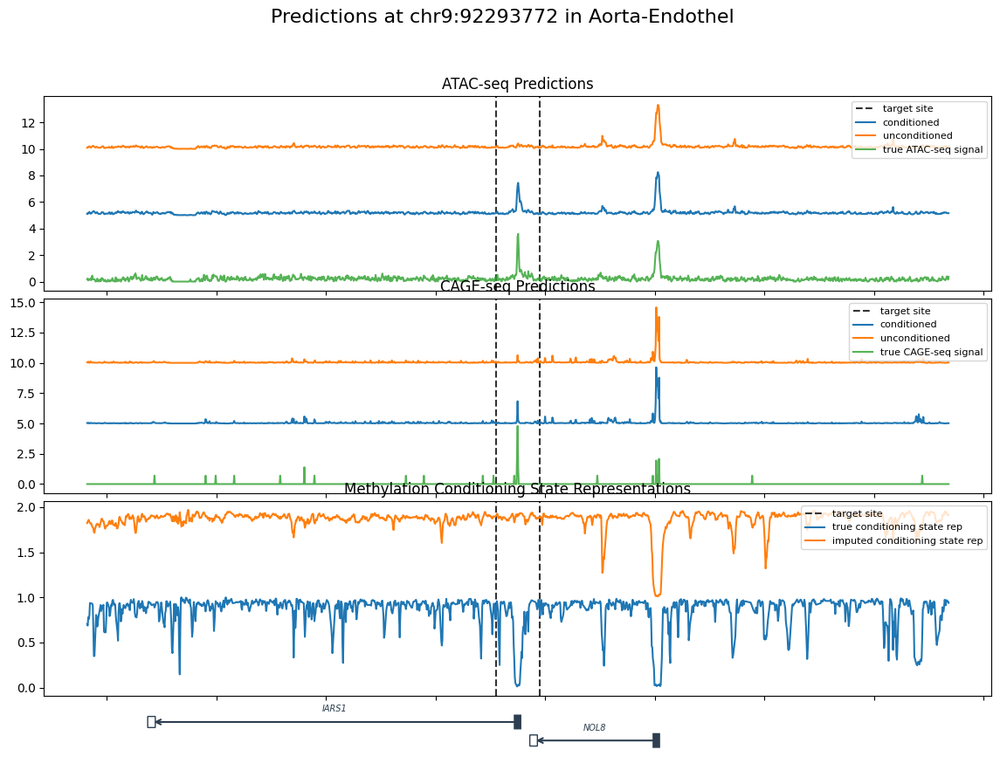

Skipping Aorta-Endothel at chr17:82593347 due to no TSS within 5000bp
Skipping Aorta-Endothel at chr6:167907034 due to no TSS within 5000bp
Skipping Aorta-Endothel at chr9:128218862 due to no TSS within 5000bp
Skipping Aorta-Endothel at chr9:128218883 due to no TSS within 5000bp
Skipping Aorta-Endothel at chr17:82593368 due to no TSS within 5000bp
Skipping Aorta-Endothel at chr6:154615776 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


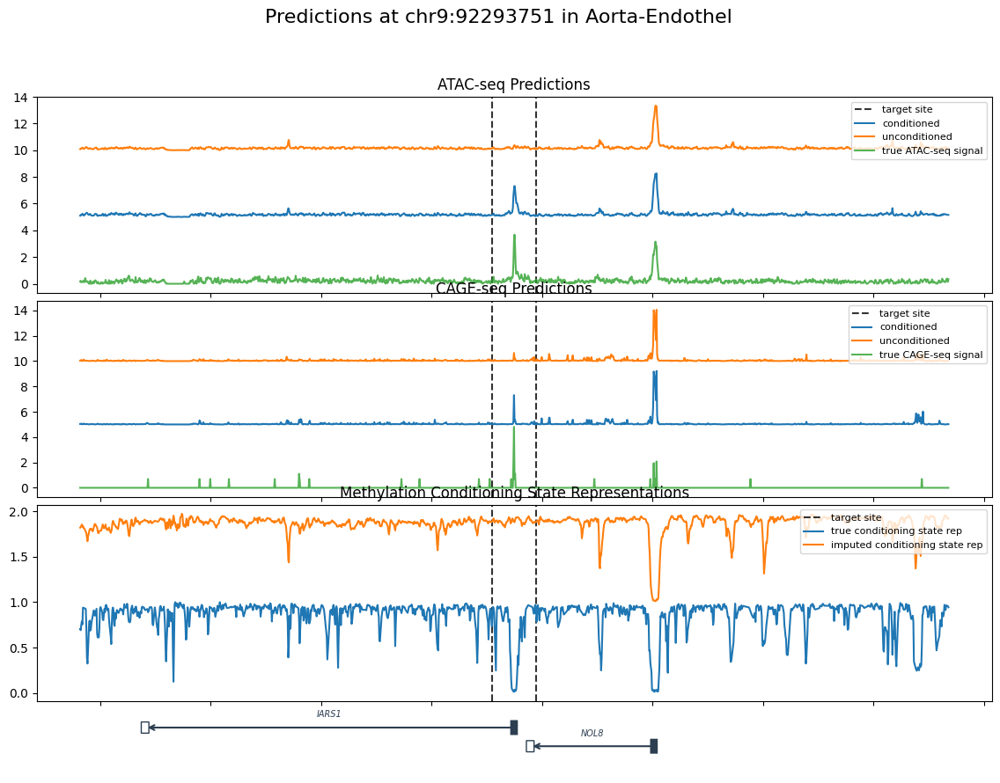

Skipping Heart-Fibroblasts at chr5:39195079 due to no TSS within 5000bp
Skipping Heart-Fibroblasts at chr9:97555453 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


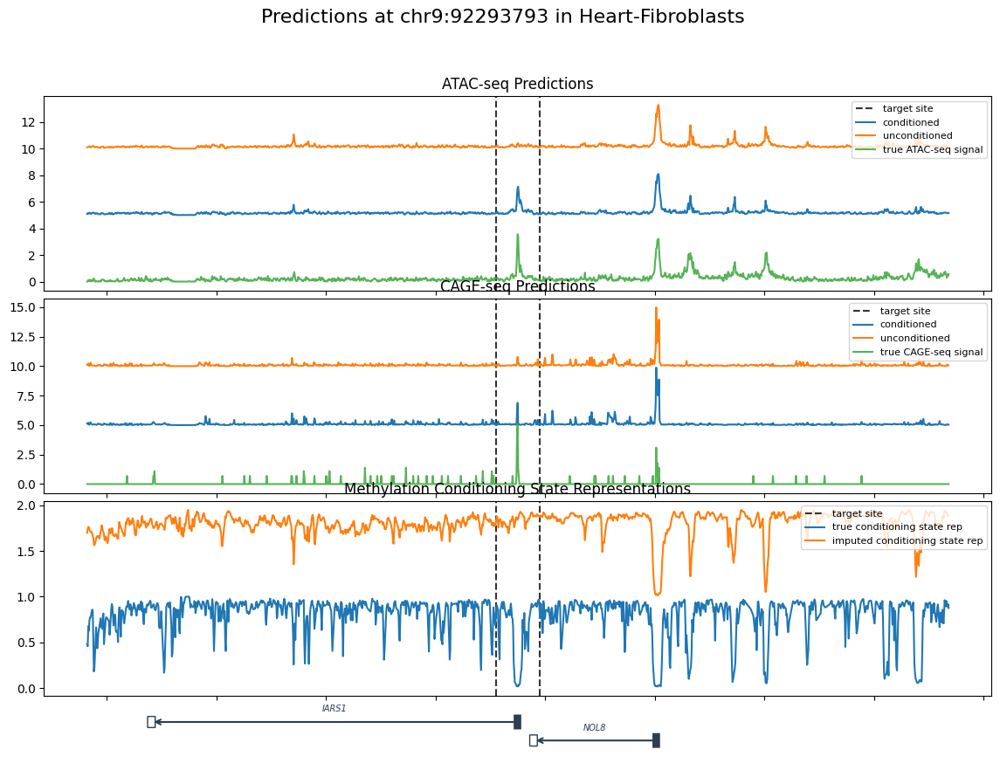

Skipping Heart-Fibroblasts at chr2:74092424 due to no TSS within 5000bp
Skipping Heart-Fibroblasts at chr6:126063713 due to no TSS within 5000bp
Skipping Heart-Fibroblasts at chr6:156316842 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


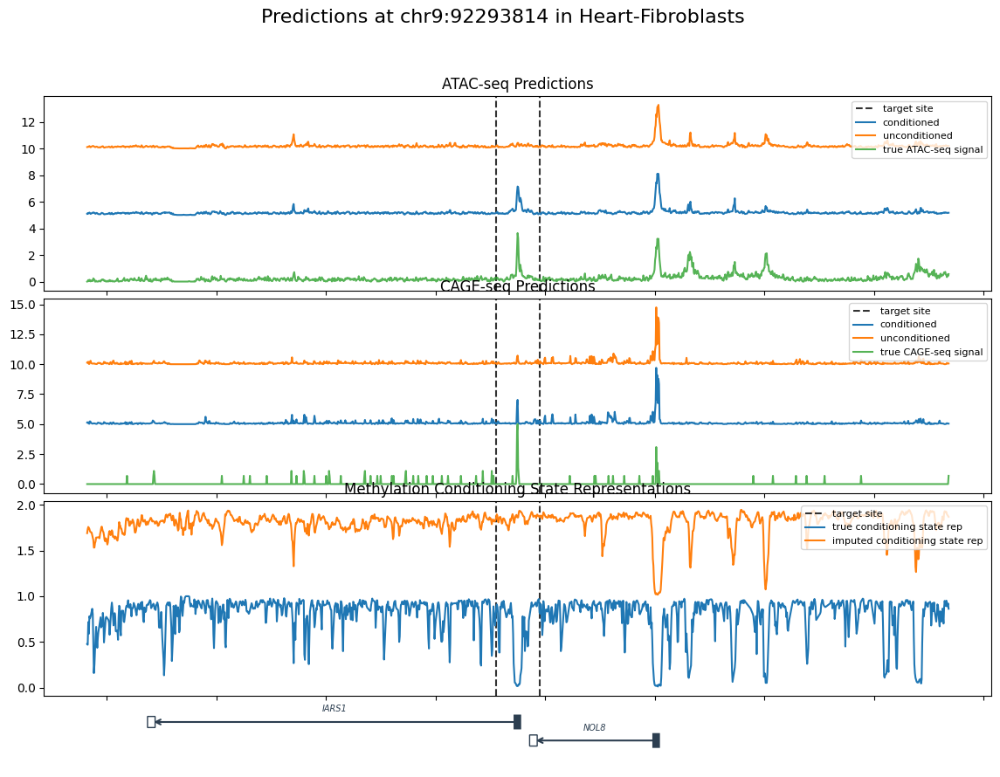

Skipping Heart-Fibroblasts at chr6:117547996 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


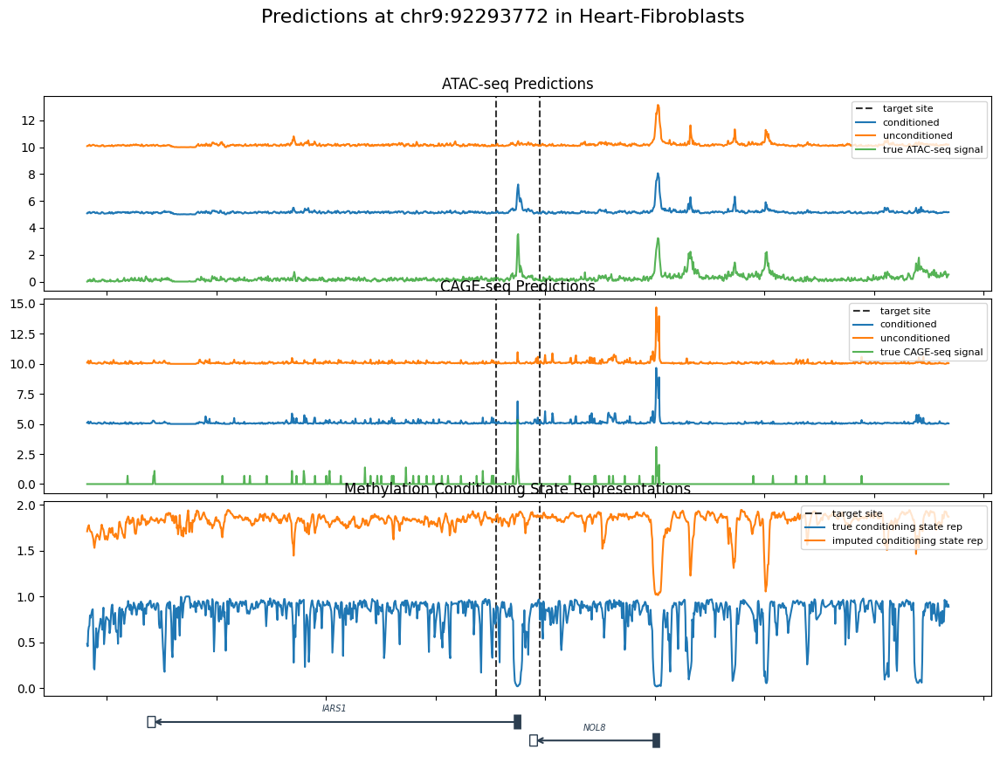

Skipping Heart-Fibroblasts at chr2:74092445 due to no TSS within 5000bp
Skipping Heart-Fibroblasts at chr13:101303672 due to no TSS within 5000bp
Skipping Heart-Fibroblasts at chr9:97555411 due to no TSS within 5000bp
Skipping Heart-Fibroblasts at chr8:47431613 due to no TSS within 5000bp
Skipping Heart-Fibroblasts at chr2:74092382 due to no TSS within 5000bp
Skipping Heart-Fibroblasts at chr11:33912958 due to no TSS within 5000bp
Skipping Heart-Fibroblasts at chr9:97555390 due to no TSS within 5000bp
Skipping Heart-Fibroblasts at chr6:117547889 due to no TSS within 5000bp
Skipping Heart-Fibroblasts at chr6:117547931 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


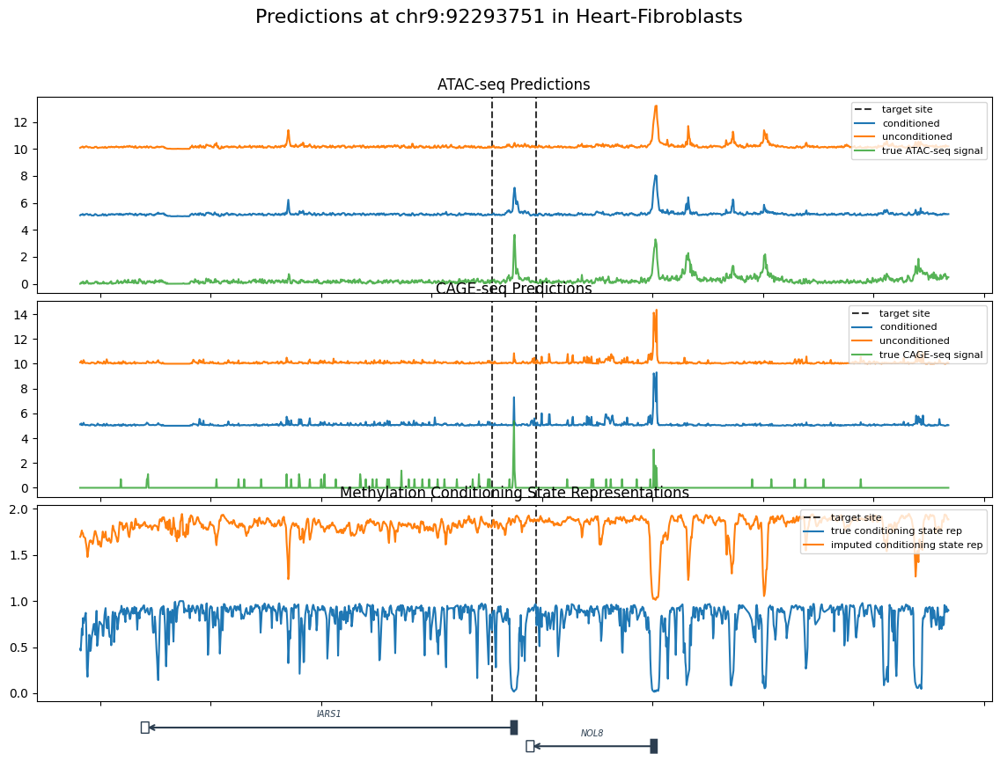

/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


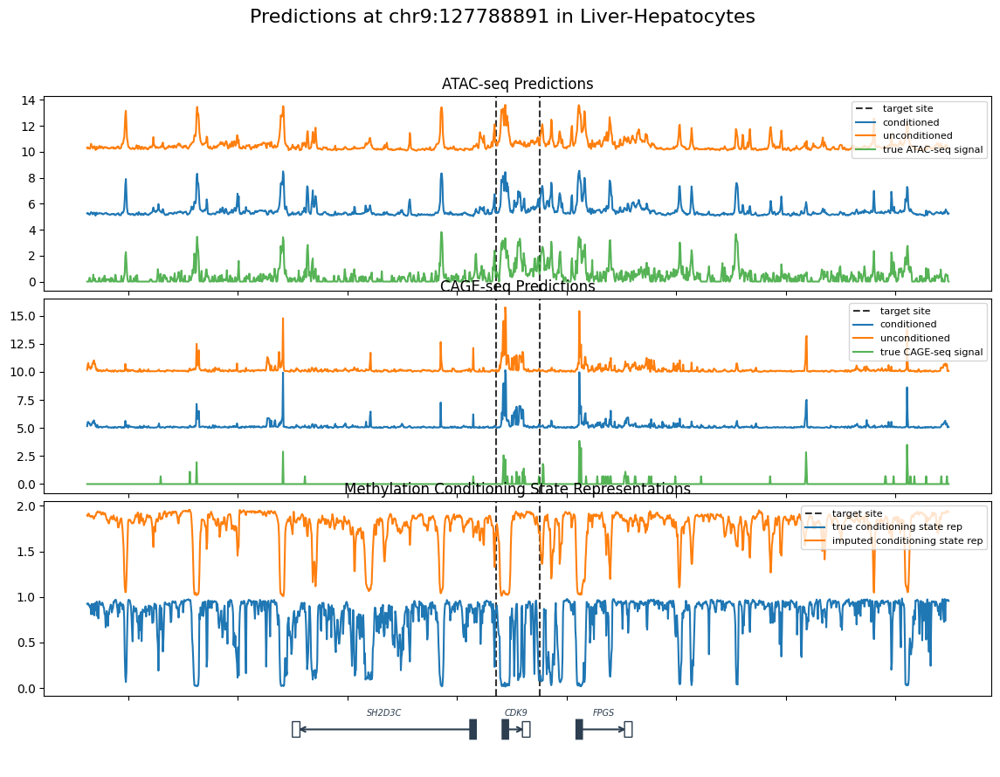

Skipping Liver-Hepatocytes at chr8:28657970 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:90916565 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr8:26323820 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr5:10601643 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:127665394 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr5:36670744 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:114176802 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:110151933 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chrX:38893080 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr8:10046376 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr8:30549626 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr6:161162974 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:117720693 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:87643457 due to no TSS w

/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


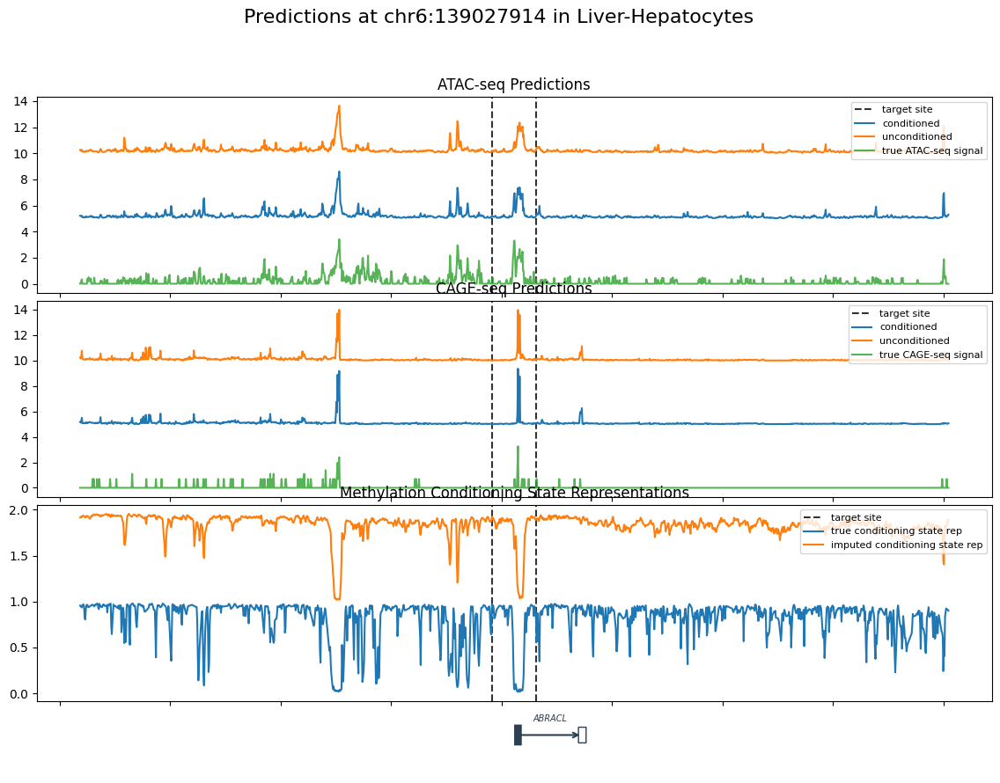

Skipping Liver-Hepatocytes at chr19:3658102 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr8:10713976 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr8:10760568 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr8:10046418 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr8:42326016 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr19:7141854 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr6:167907120 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr8:11853424 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:125461057 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr8:26323841 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr5:33229488 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr5:14685008 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr5:14705744 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:117720800 due to no TSS wit

/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


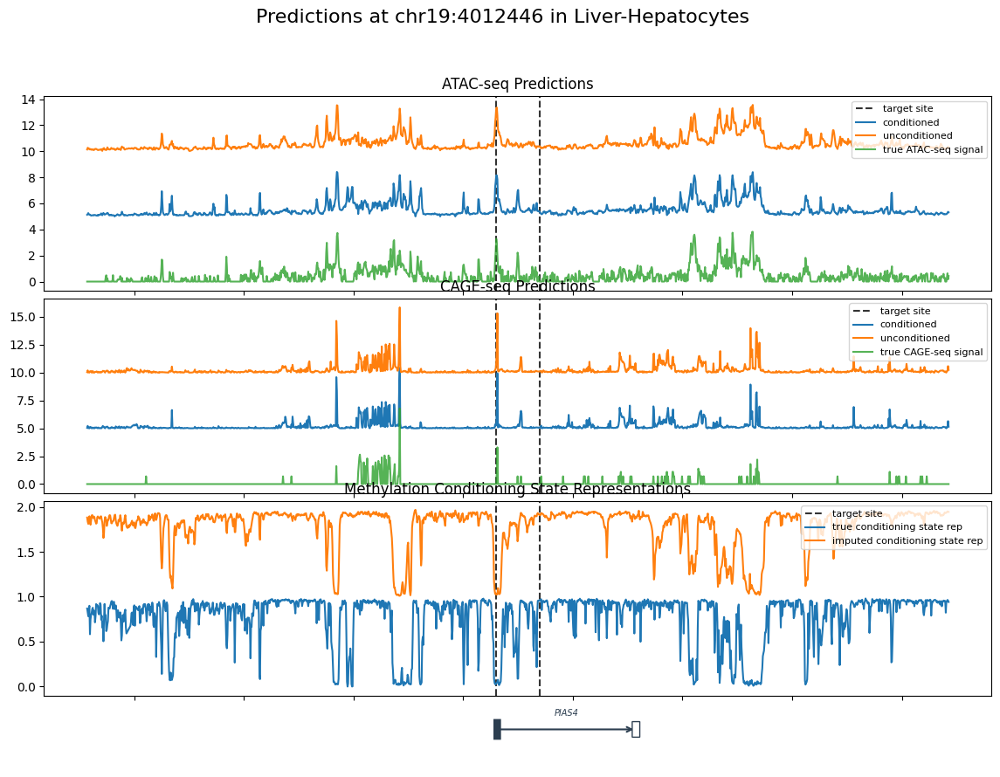

Skipping Liver-Hepatocytes at chr13:100075841 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr7:70475005 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


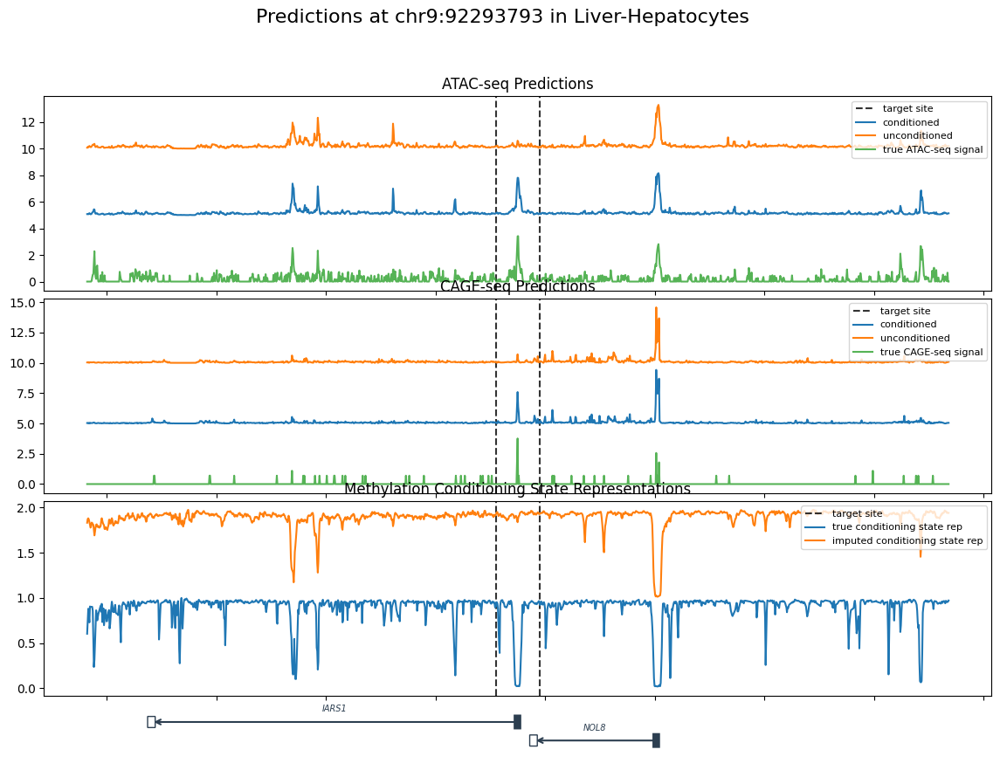

Skipping Liver-Hepatocytes at chr11:47966815 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr6:160356559 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:127665308 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


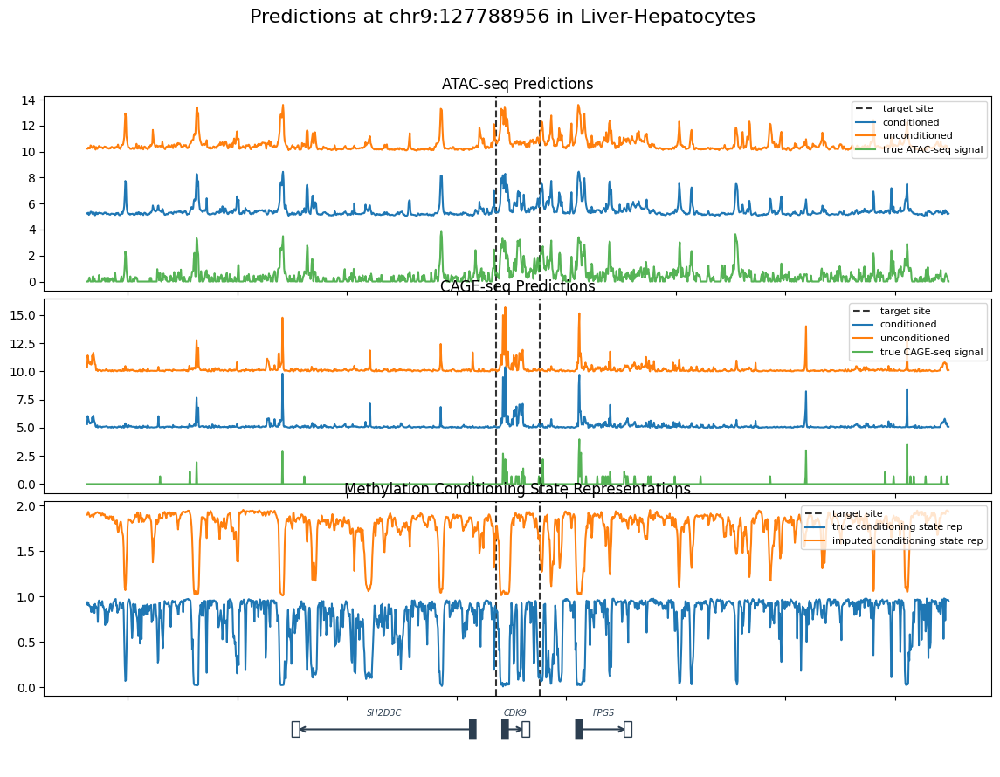

Skipping Liver-Hepatocytes at chr2:88177769 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr8:48396322 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr2:68946283 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:114176823 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr13:94344616 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr8:42325930 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr13:57046289 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:93024455 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr8:10691299 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr8:10713955 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr8:10760547 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr19:3658123 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr13:73337016 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:92616949 due to no TSS wi

/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


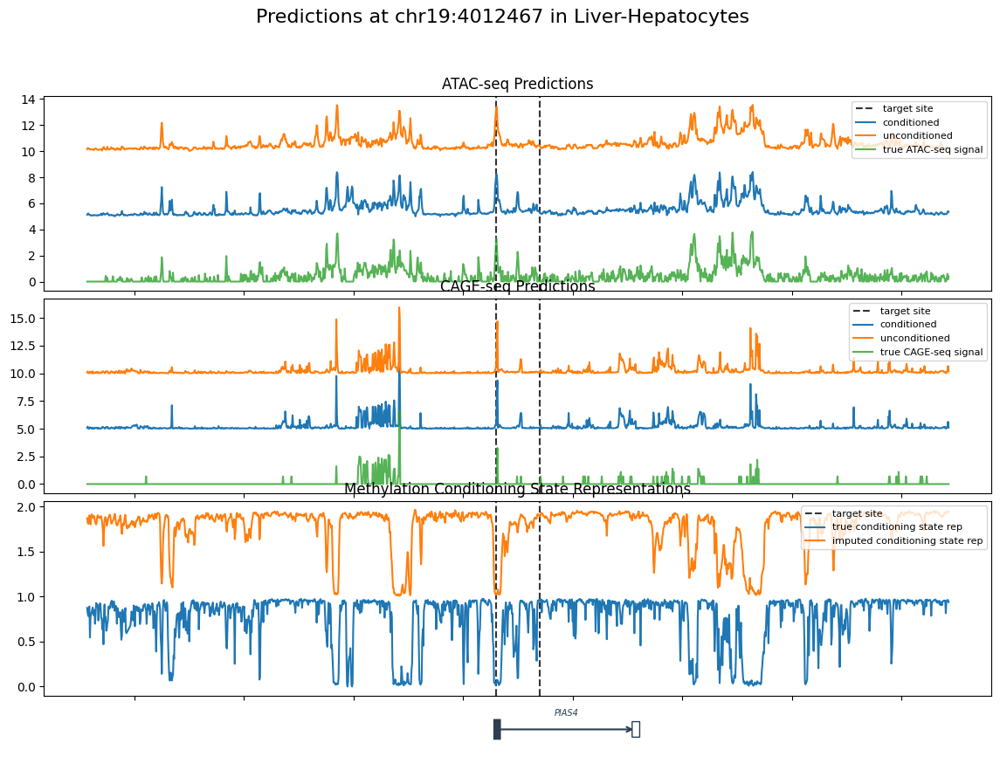

/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


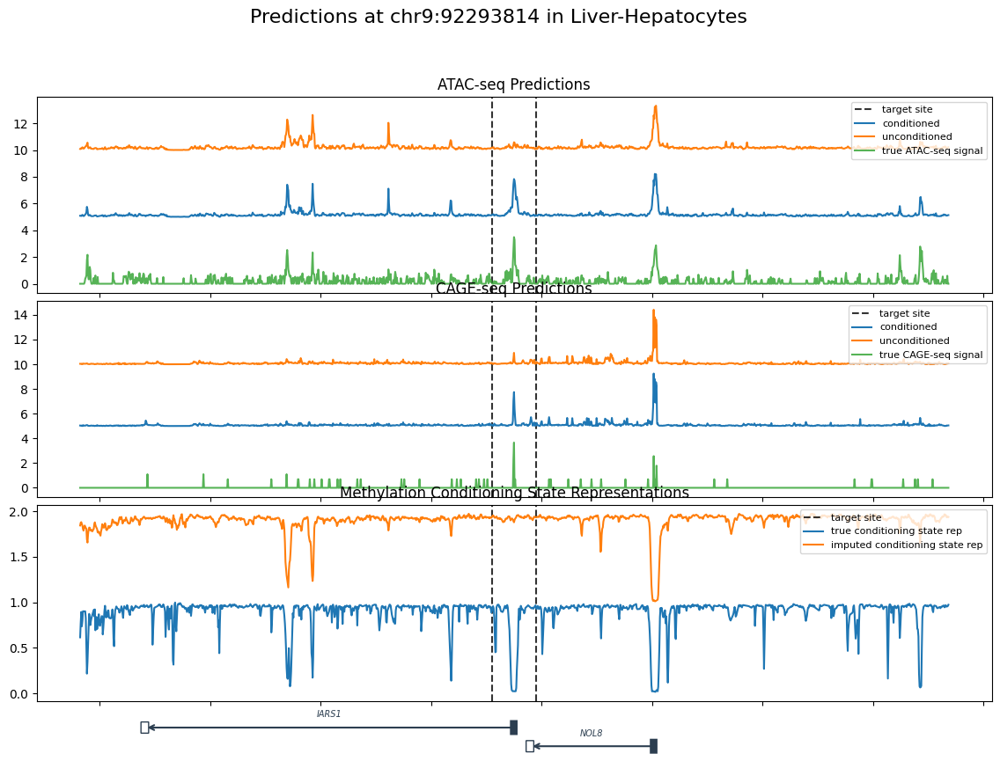

Skipping Liver-Hepatocytes at chr9:134408618 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:134422442 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr8:28658033 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr7:73358164 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr8:26323734 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:121296007 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr19:5594728 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr13:42832932 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr8:21696673 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr2:68946390 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:117720735 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


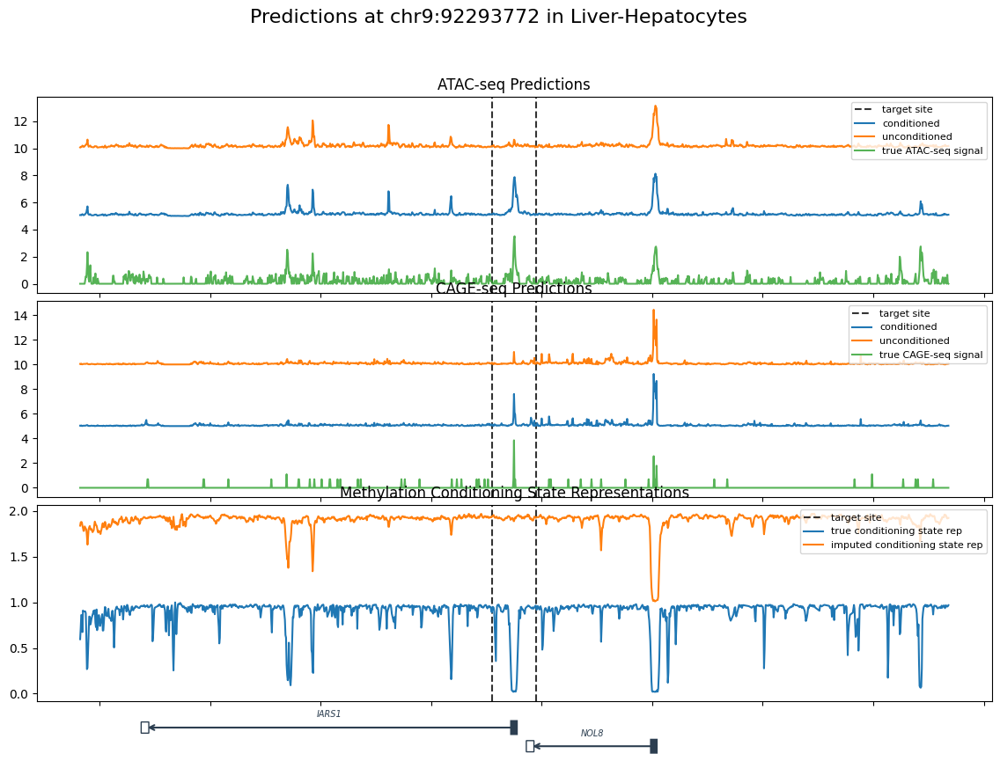

Skipping Liver-Hepatocytes at chr2:88177790 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


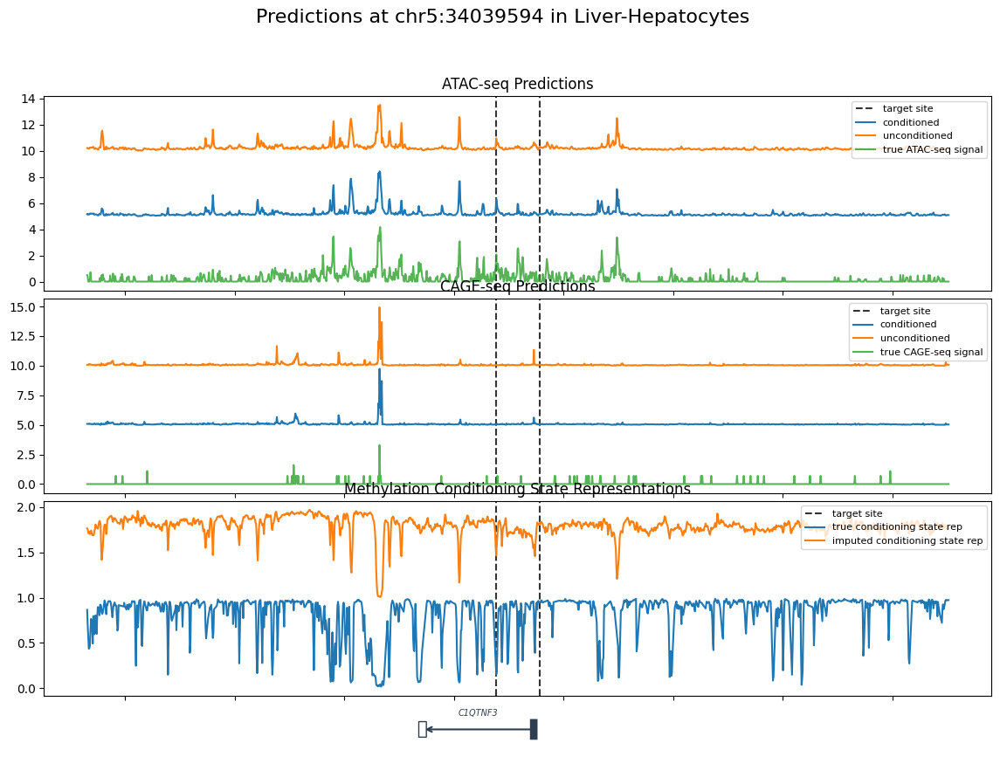

Skipping Liver-Hepatocytes at chr2:121809811 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr13:73336995 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:81820158 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


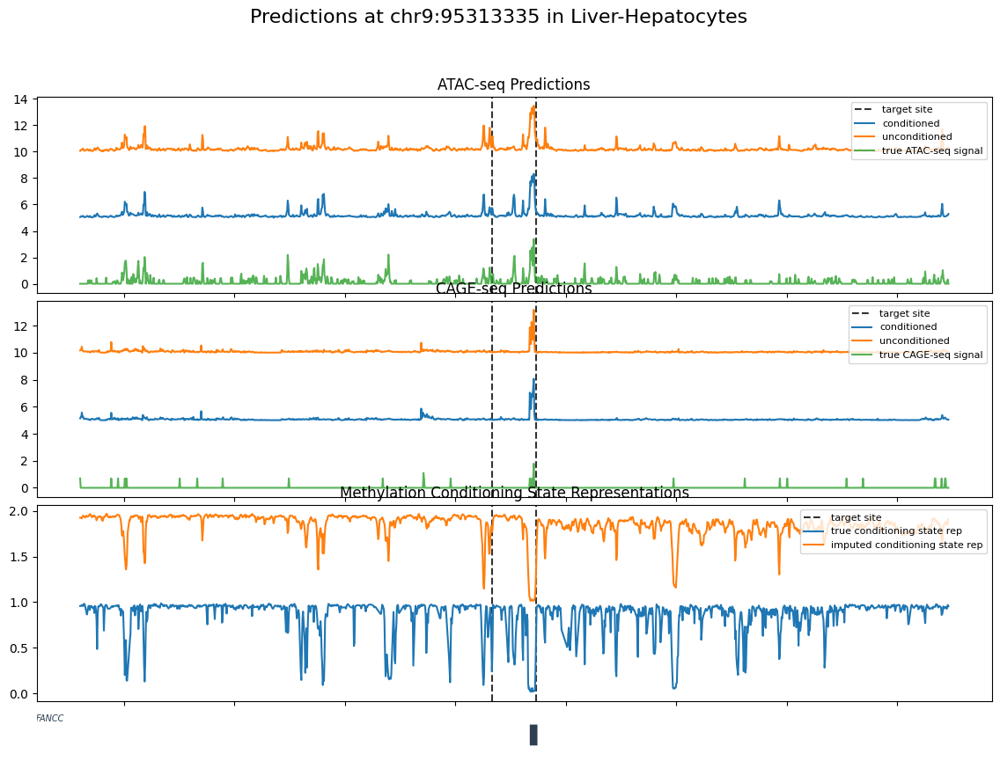

Skipping Liver-Hepatocytes at chr8:26323799 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:94983695 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr11:45912536 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:134408597 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:134422421 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:90611736 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:133881949 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr19:3658165 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:104903841 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr2:68946325 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr11:44979166 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr13:41721025 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr6:168886719 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:124363549 due to no T

/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


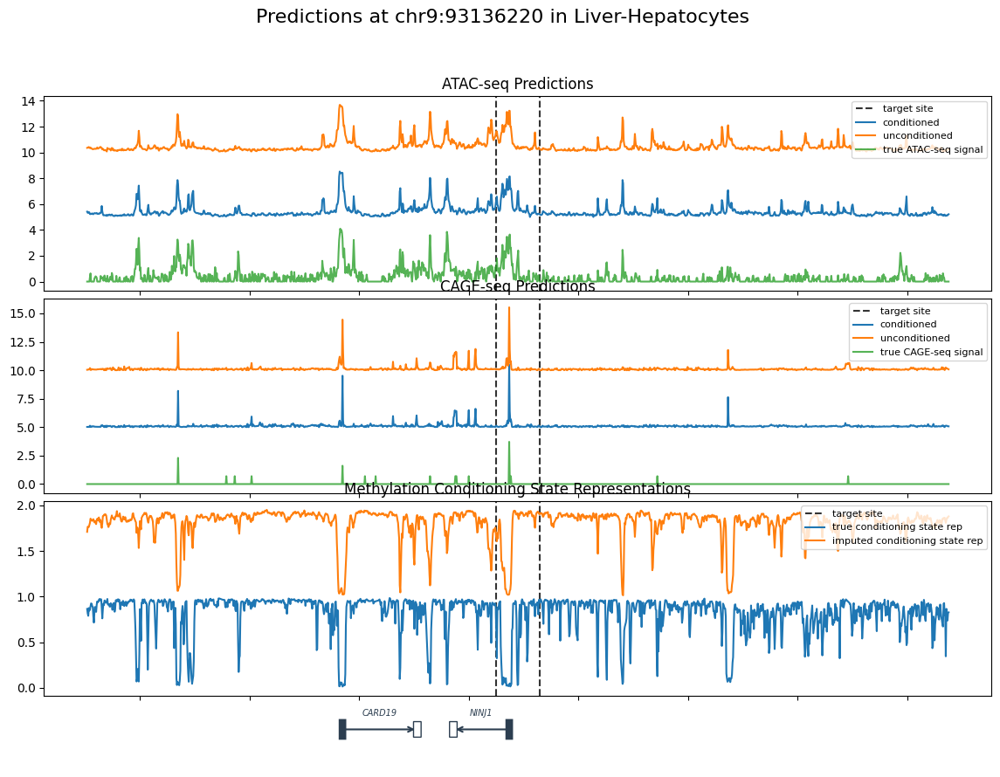

/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


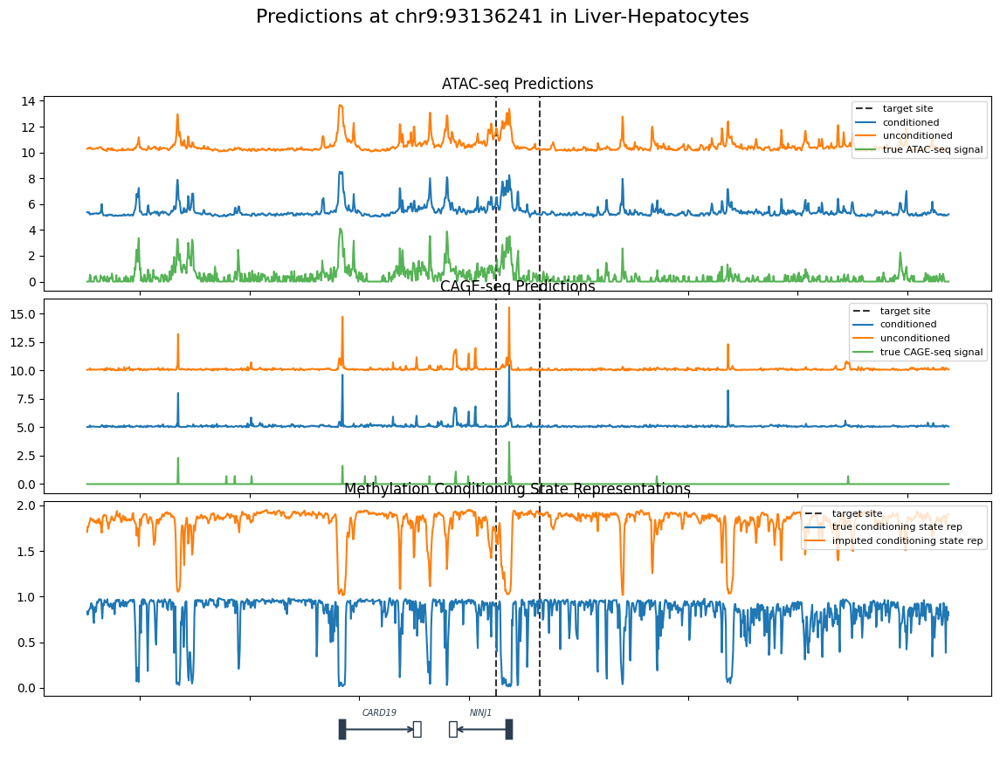

Skipping Liver-Hepatocytes at chr19:7257373 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr6:111730990 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr8:26693866 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr6:108989846 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


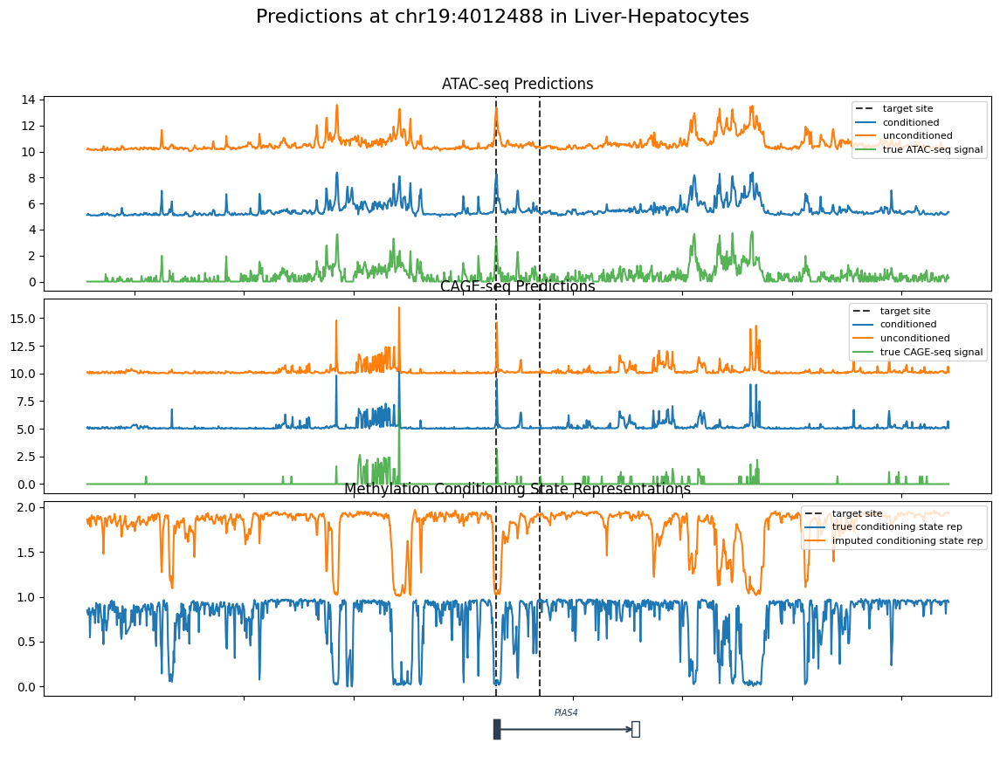

Skipping Liver-Hepatocytes at chr13:98809503 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr13:98824607 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr13:98827679 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


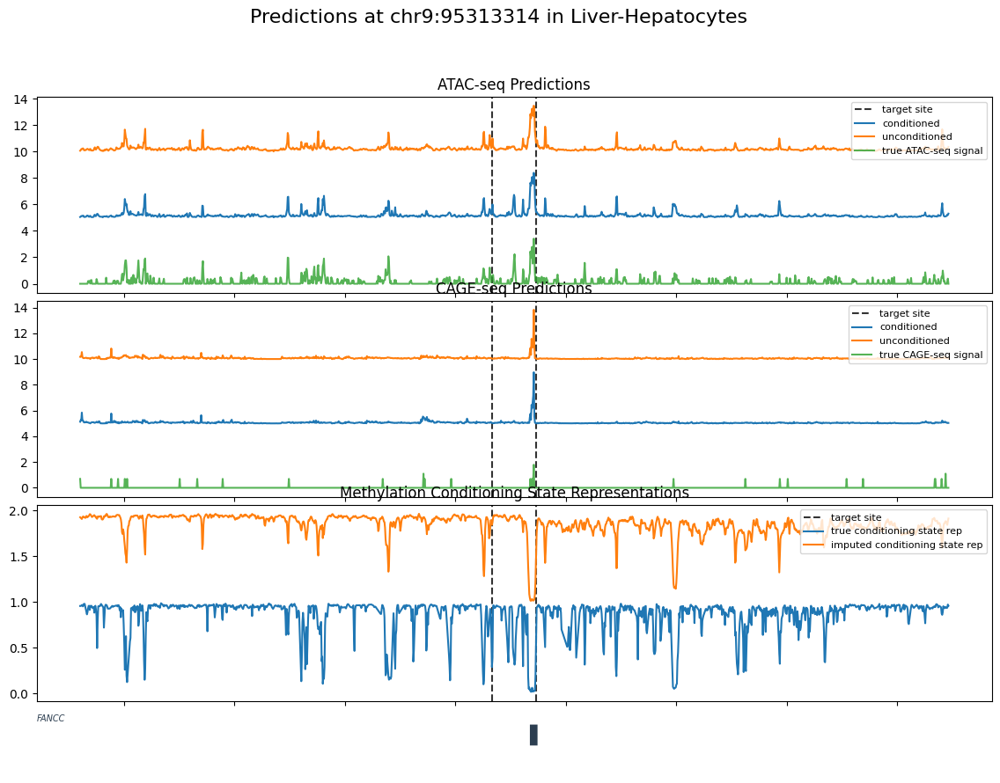

Skipping Liver-Hepatocytes at chr2:88177704 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr19:7257352 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr13:42832911 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr19:7257331 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr8:10046397 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr6:145044812 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr6:167907034 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr11:45912450 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr6:160356580 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr6:131368702 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr13:99559684 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr13:98824542 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr13:94344637 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr11:47966836 due to no 

/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


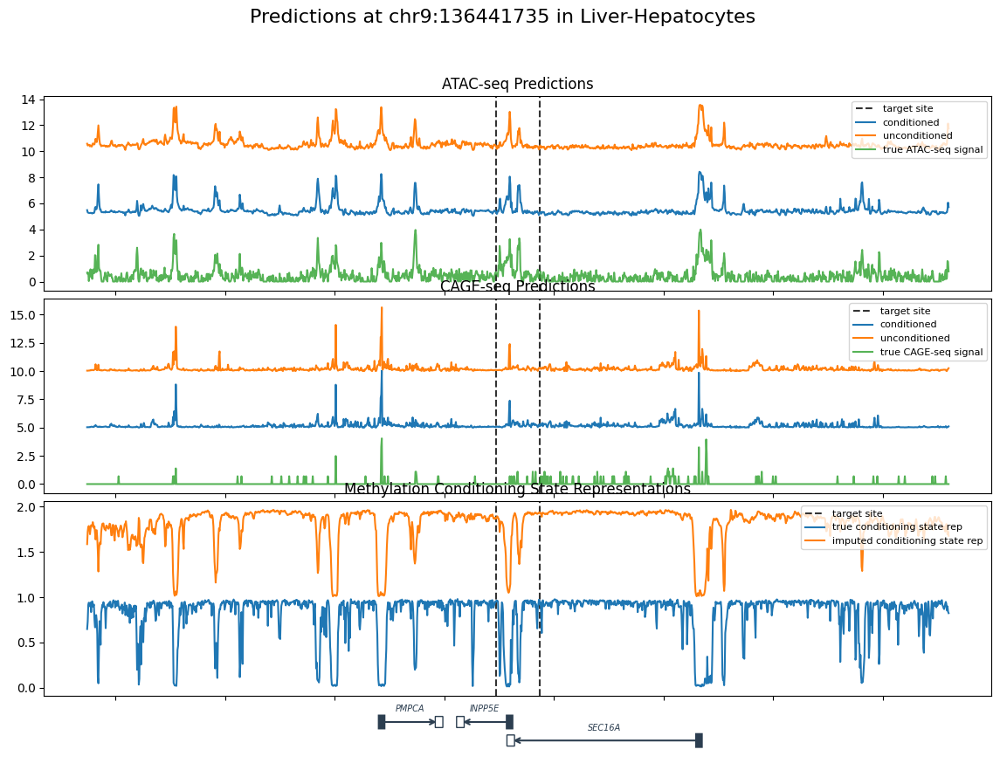

Skipping Liver-Hepatocytes at chr9:124363570 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:92098274 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:117720714 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr19:3338744 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr19:3350520 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr7:74043237 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:133881842 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr6:128005247 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:110151912 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr11:44979187 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr8:26693908 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:92098253 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr11:28170192 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr7:73358078 due to no TSS

/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


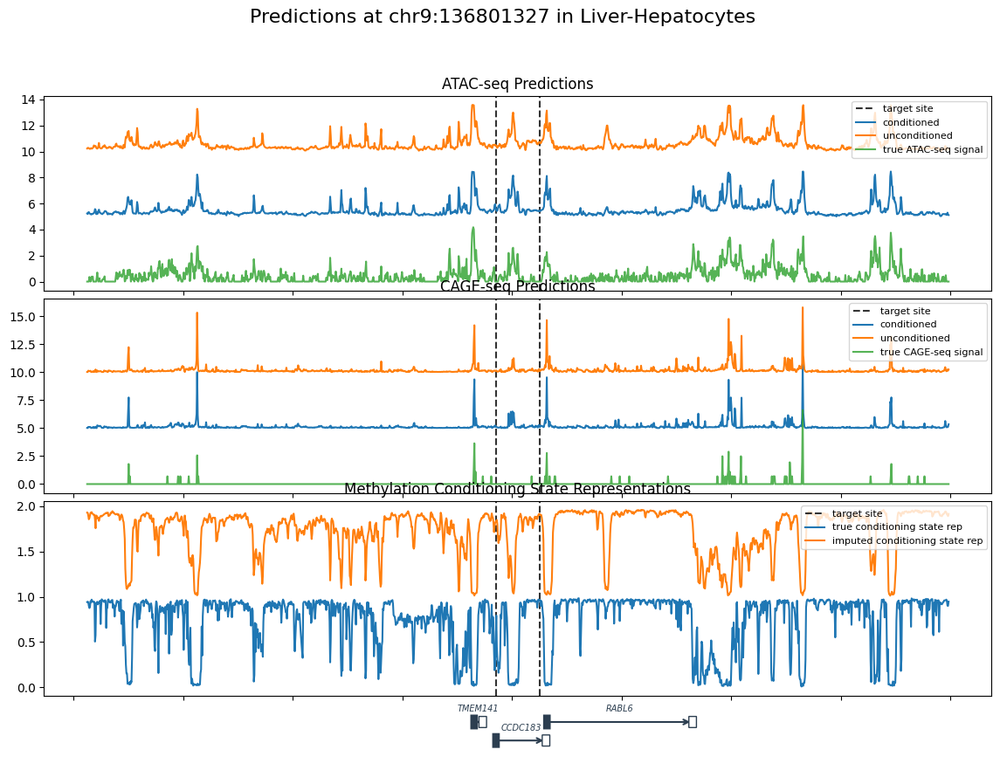

Skipping Liver-Hepatocytes at chr13:46675701 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr6:151629940 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr5:14922660 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:128218862 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr11:47966794 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:94983781 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr6:167907013 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr5:33229467 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


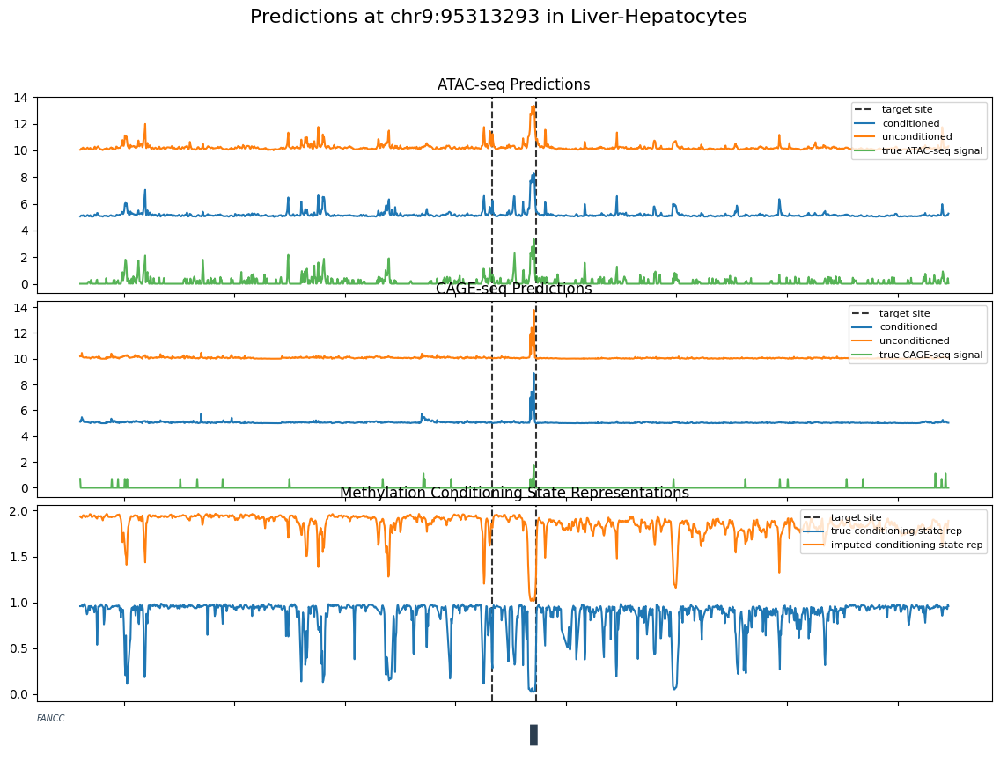

Skipping Liver-Hepatocytes at chr9:94983674 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:137670932 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:104903862 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:128218883 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr19:5594707 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:83962308 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr13:100075883 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:121295965 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr19:3347106 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr6:161162911 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:83962245 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr19:3338765 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


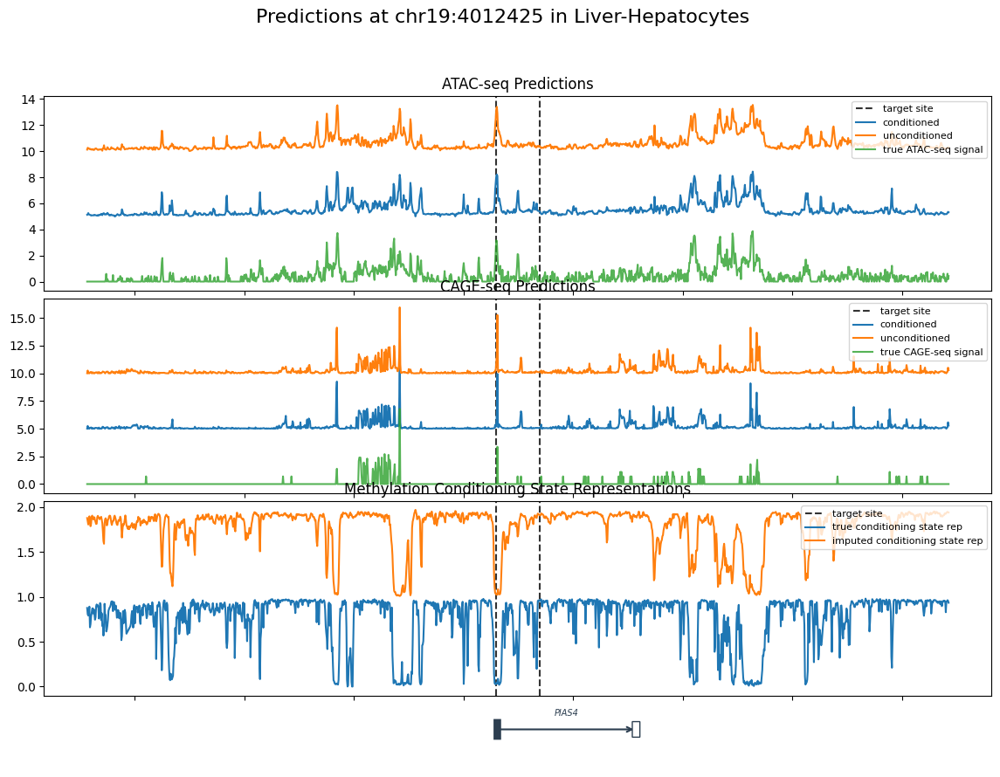

Skipping Liver-Hepatocytes at chr17:82593368 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr19:3658144 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


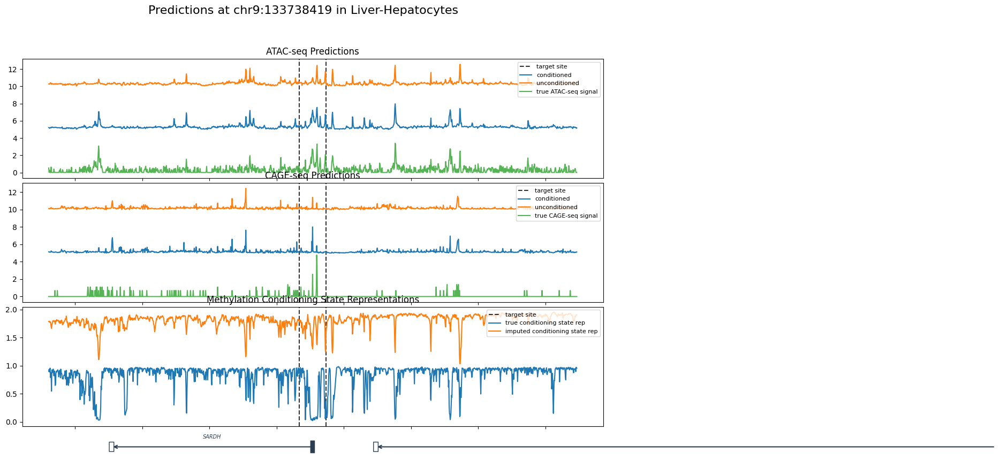

Skipping Liver-Hepatocytes at chr9:110151891 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr6:132768137 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:134408660 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr11:35827121 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr11:44979252 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr6:167907099 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:133881863 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:125461099 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


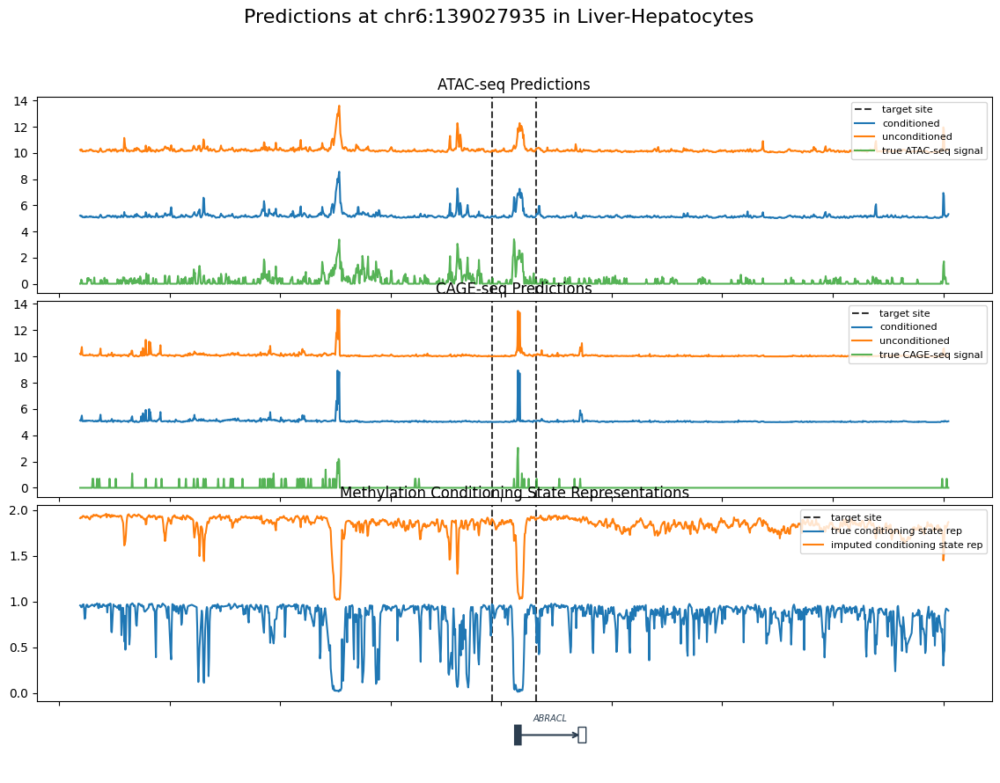

Skipping Liver-Hepatocytes at chr19:3338723 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr19:3350499 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:81820179 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr15:29942734 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:92098232 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


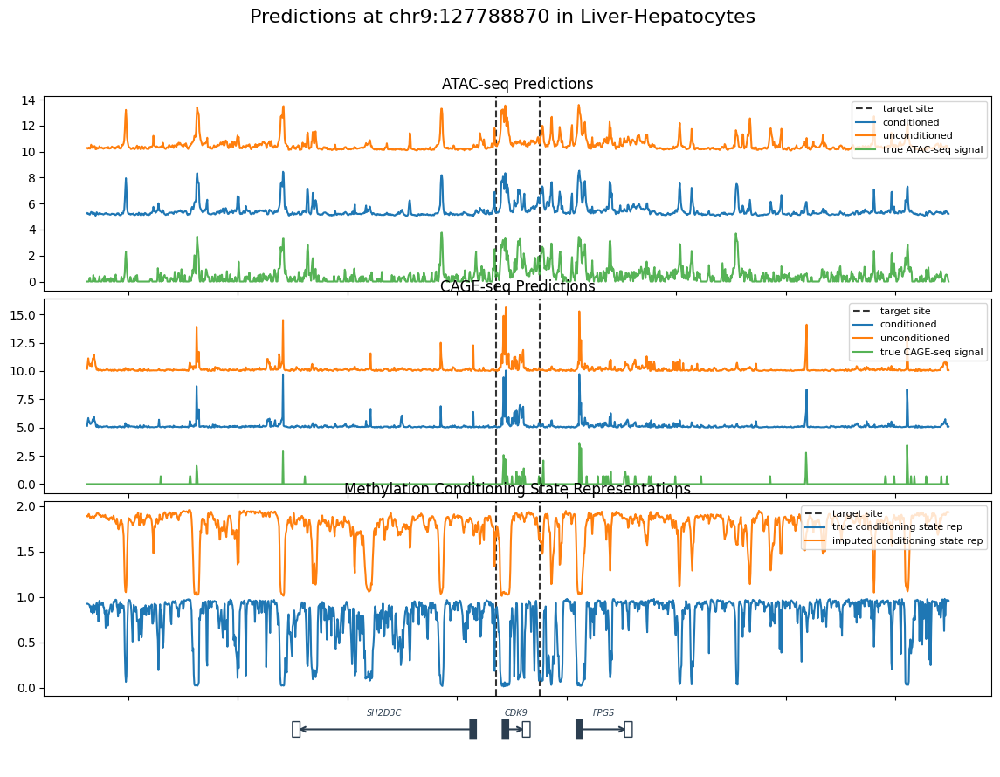

Skipping Liver-Hepatocytes at chr9:124363507 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:133881928 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:134408639 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:134418623 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:134422463 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr2:70140366 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


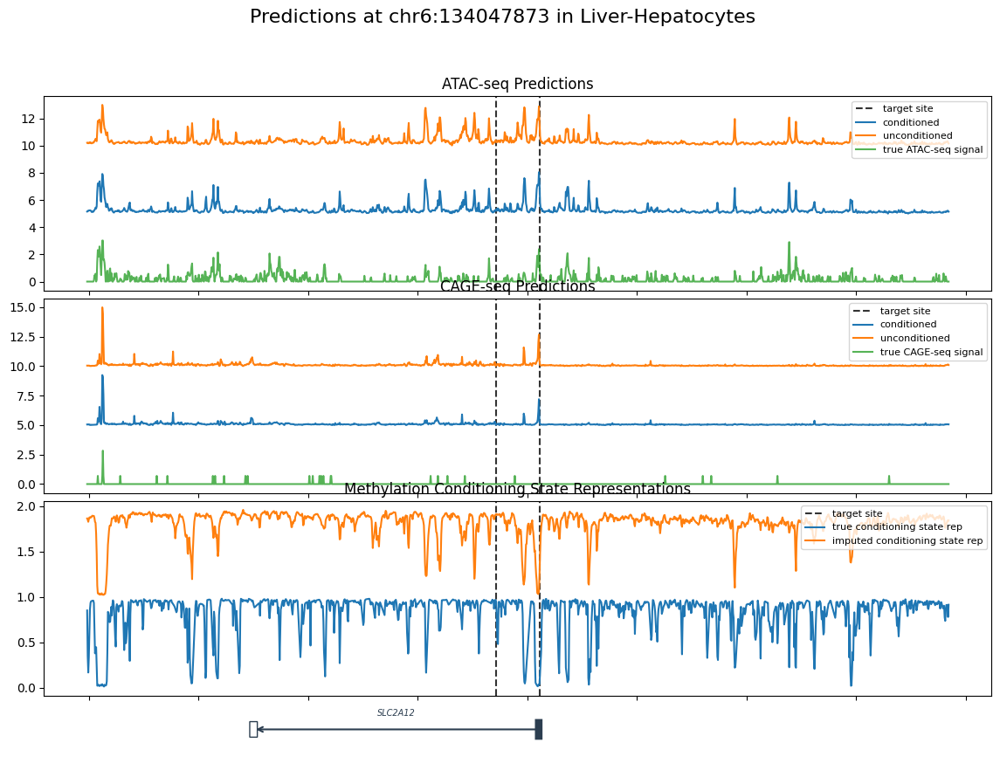

Skipping Liver-Hepatocytes at chr8:11853403 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr7:70602300 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:90916544 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:127665329 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


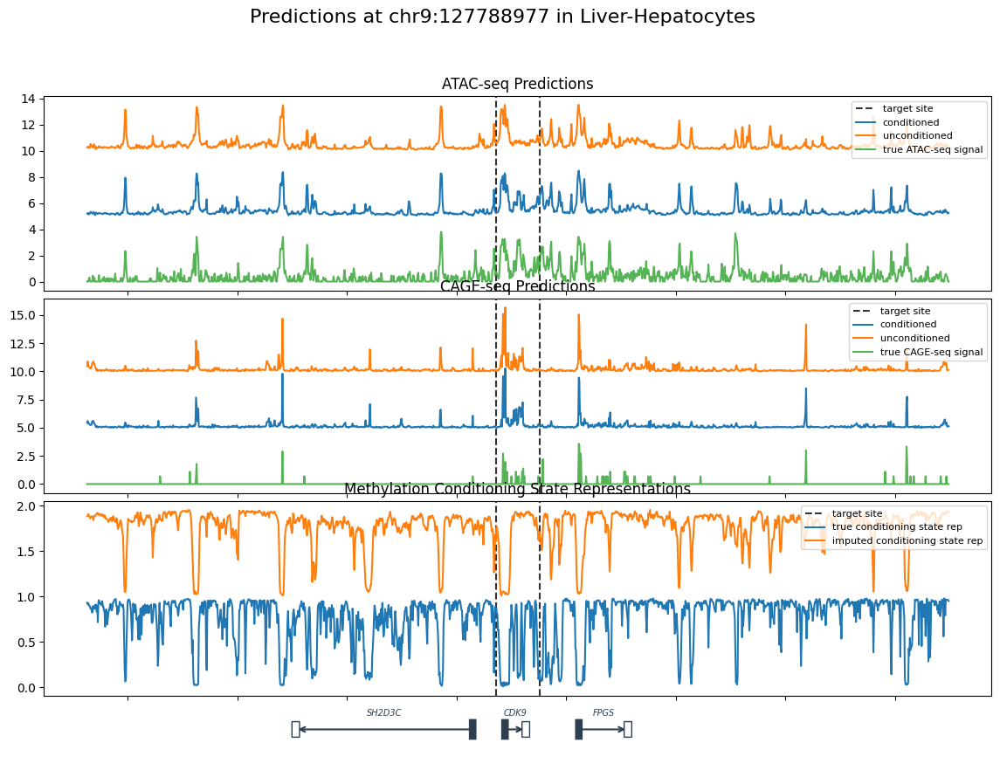

Skipping Liver-Hepatocytes at chr9:108869318 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


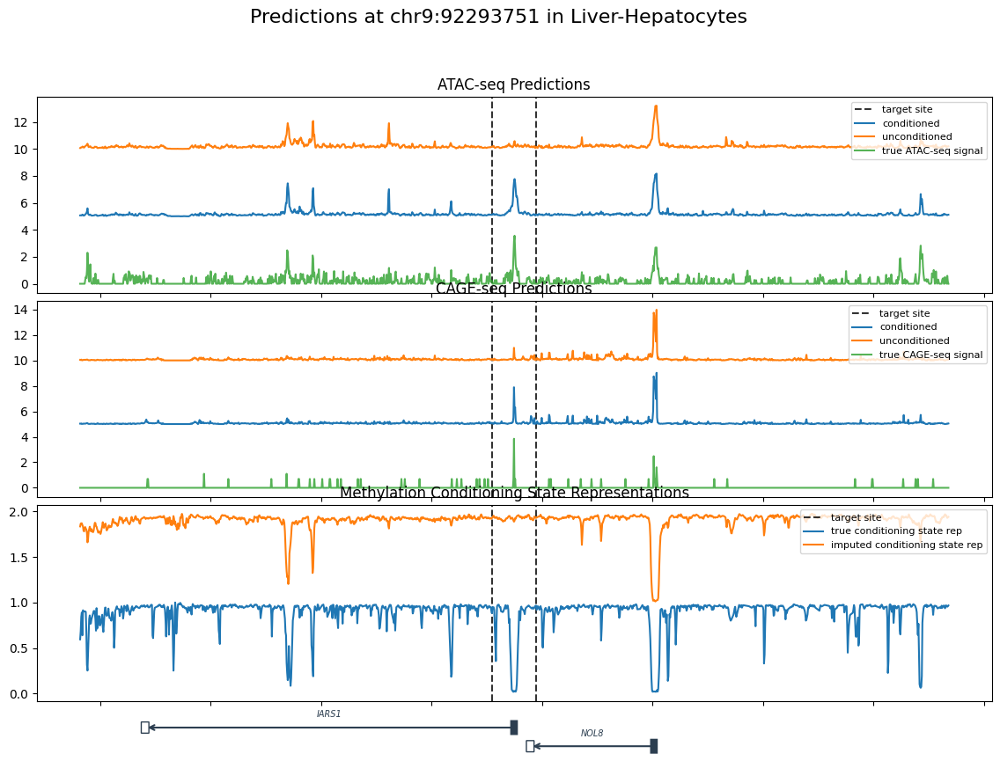

Skipping Liver-Hepatocytes at chr13:46675722 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr13:94344679 due to no TSS within 5000bp
Skipping Liver-Hepatocytes at chr9:81820093 due to no TSS within 5000bp
Skipping Lung-Interstitial-Macrophages at chr9:90964437 due to no TSS within 5000bp
Skipping Lung-Interstitial-Macrophages at chr8:40174862 due to no TSS within 5000bp
Skipping Lung-Interstitial-Macrophages at chr19:6509538 due to no TSS within 5000bp
Skipping Lung-Interstitial-Macrophages at chr6:148831196 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


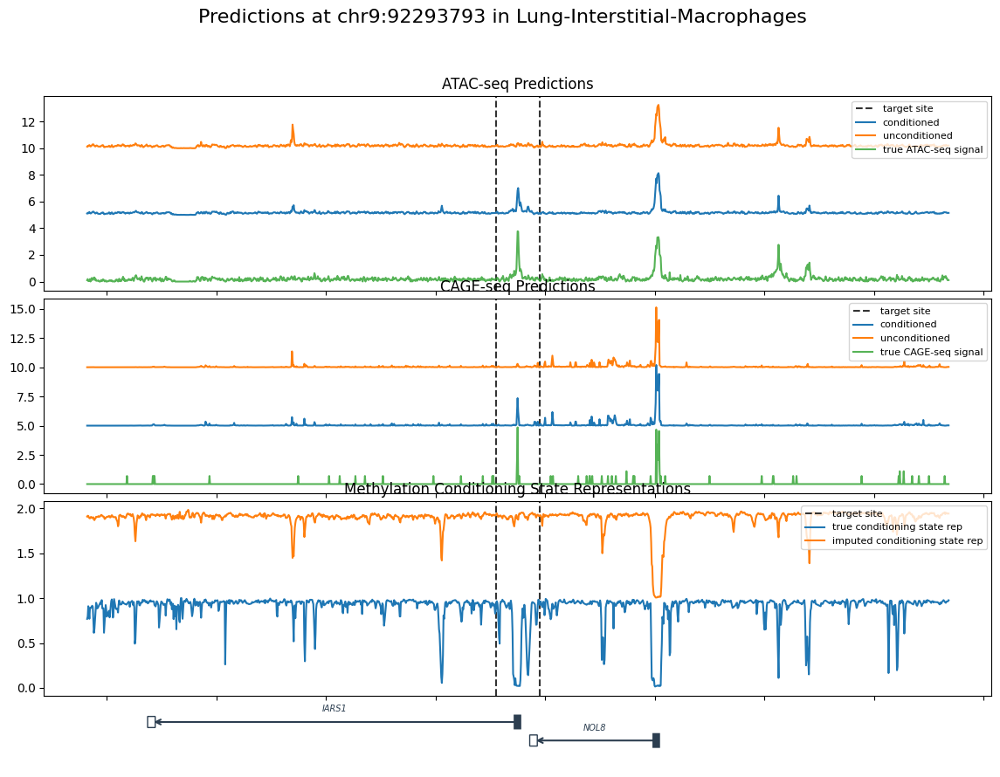

/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


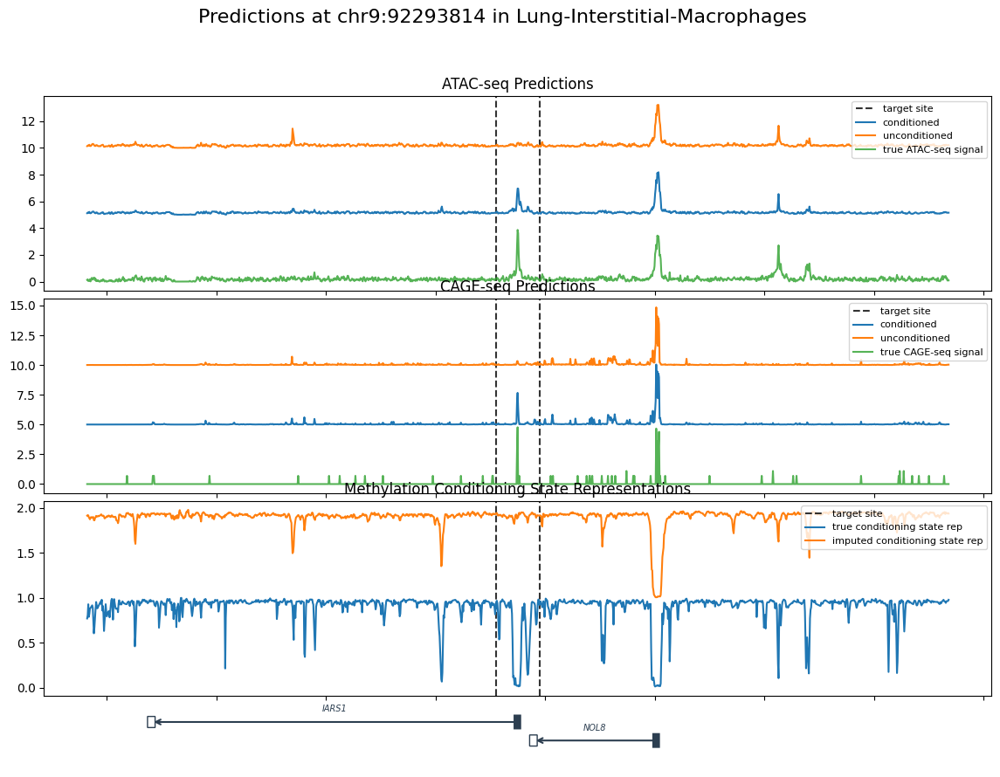

Skipping Lung-Interstitial-Macrophages at chr6:117547996 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


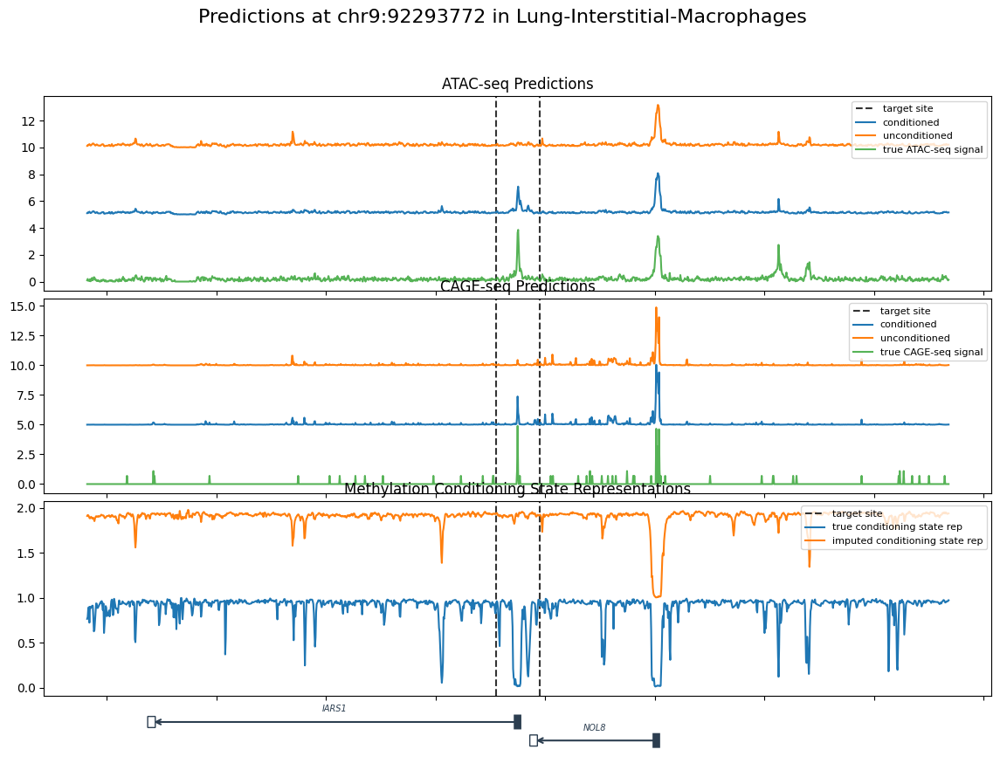

Skipping Lung-Interstitial-Macrophages at chr8:40174883 due to no TSS within 5000bp
Skipping Lung-Interstitial-Macrophages at chr6:148831282 due to no TSS within 5000bp
Skipping Lung-Interstitial-Macrophages at chr9:90964458 due to no TSS within 5000bp
Skipping Lung-Interstitial-Macrophages at chr6:117547910 due to no TSS within 5000bp
Skipping Lung-Interstitial-Macrophages at chr9:128218862 due to no TSS within 5000bp
Skipping Lung-Interstitial-Macrophages at chr9:128218883 due to no TSS within 5000bp
Skipping Lung-Interstitial-Macrophages at chr6:150167699 due to no TSS within 5000bp
Skipping Lung-Interstitial-Macrophages at chr6:117547889 due to no TSS within 5000bp
Skipping Lung-Interstitial-Macrophages at chr6:154615776 due to no TSS within 5000bp
Skipping Lung-Interstitial-Macrophages at chr6:117547931 due to no TSS within 5000bp
Skipping Lung-Interstitial-Macrophages at chr9:90964416 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


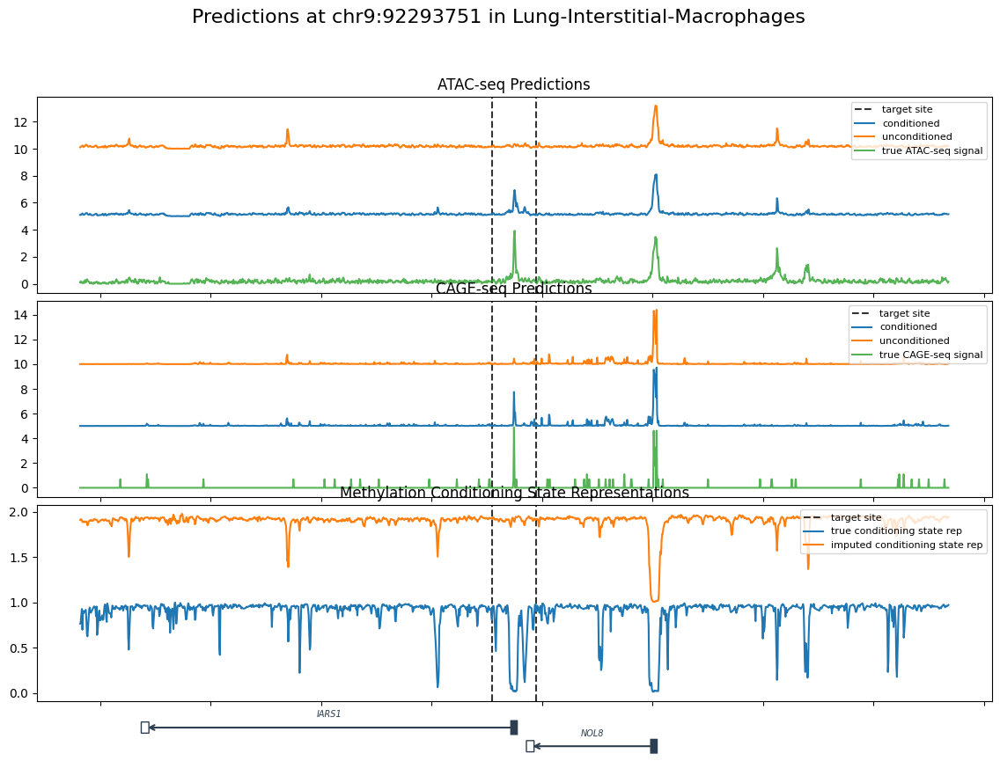

Skipping Pancreas-Islet-Endothel at chr8:40040164 due to no TSS within 5000bp
Skipping Pancreas-Islet-Endothel at chr8:40040185 due to no TSS within 5000bp
Skipping Pancreas-Islet-Endothel at chr8:40040122 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


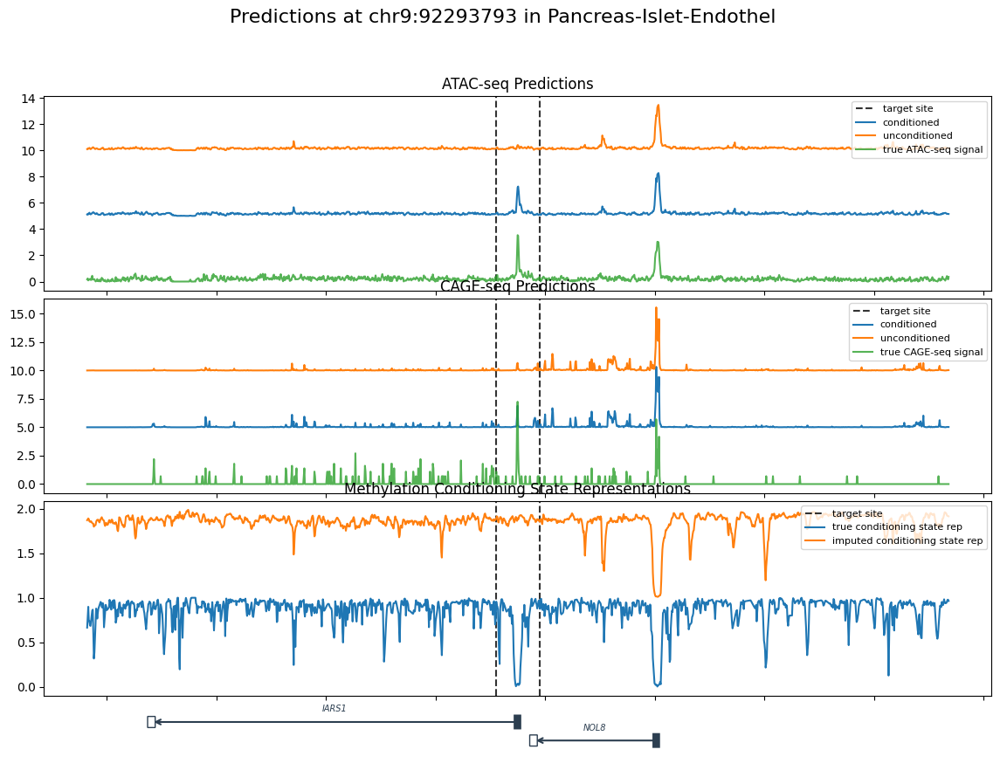

Skipping Pancreas-Islet-Endothel at chr6:154488972 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


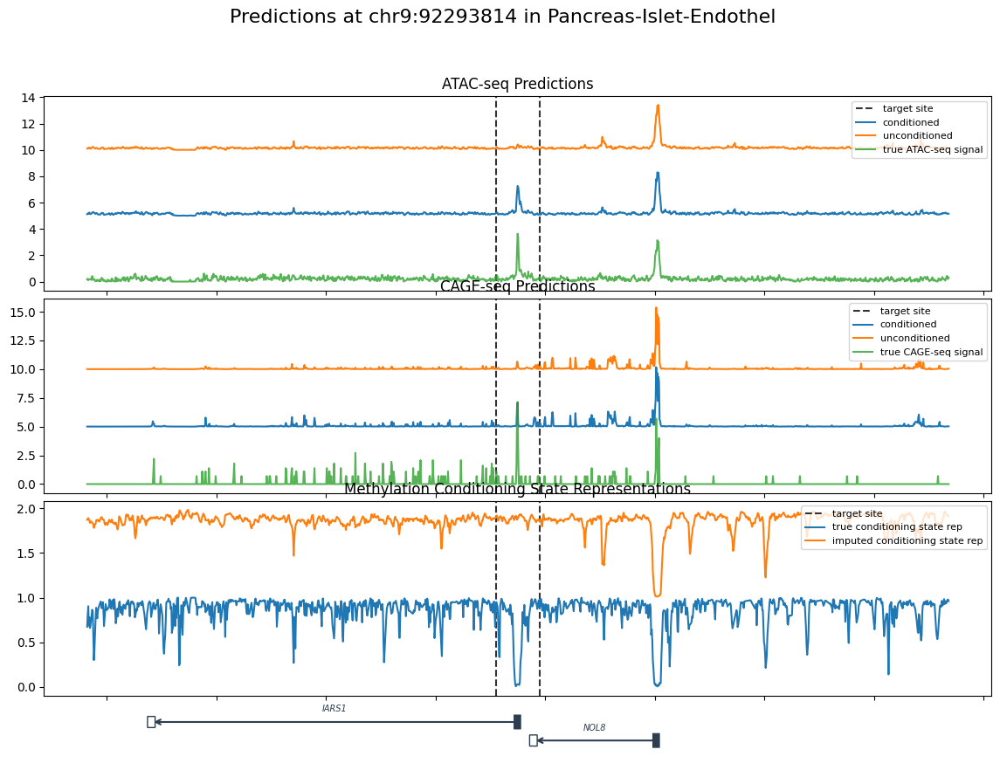

/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


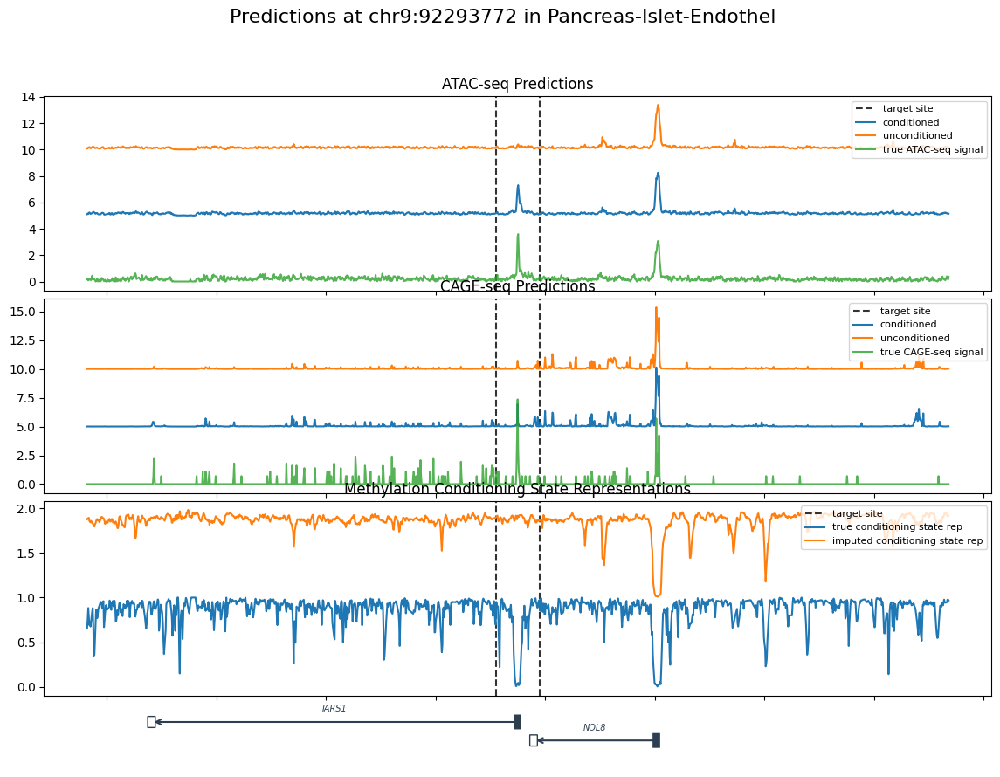

Skipping Pancreas-Islet-Endothel at chr17:82593347 due to no TSS within 5000bp
Skipping Pancreas-Islet-Endothel at chr6:117549190 due to no TSS within 5000bp
Skipping Pancreas-Islet-Endothel at chr13:95271351 due to no TSS within 5000bp
Skipping Pancreas-Islet-Endothel at chr17:82593368 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


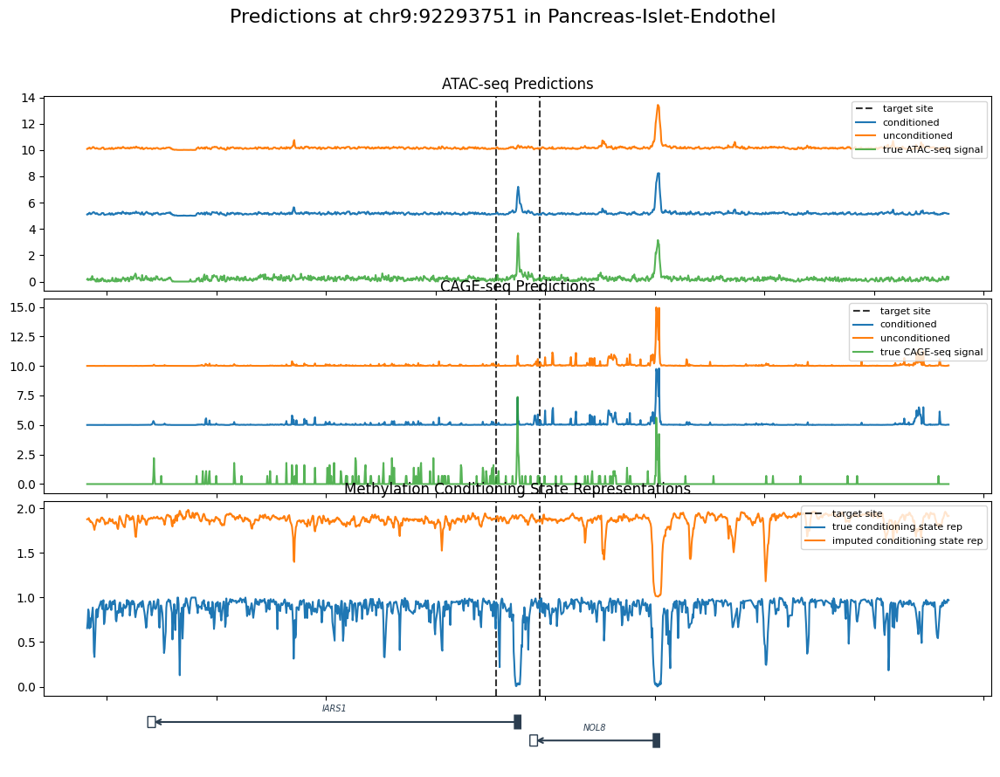

/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


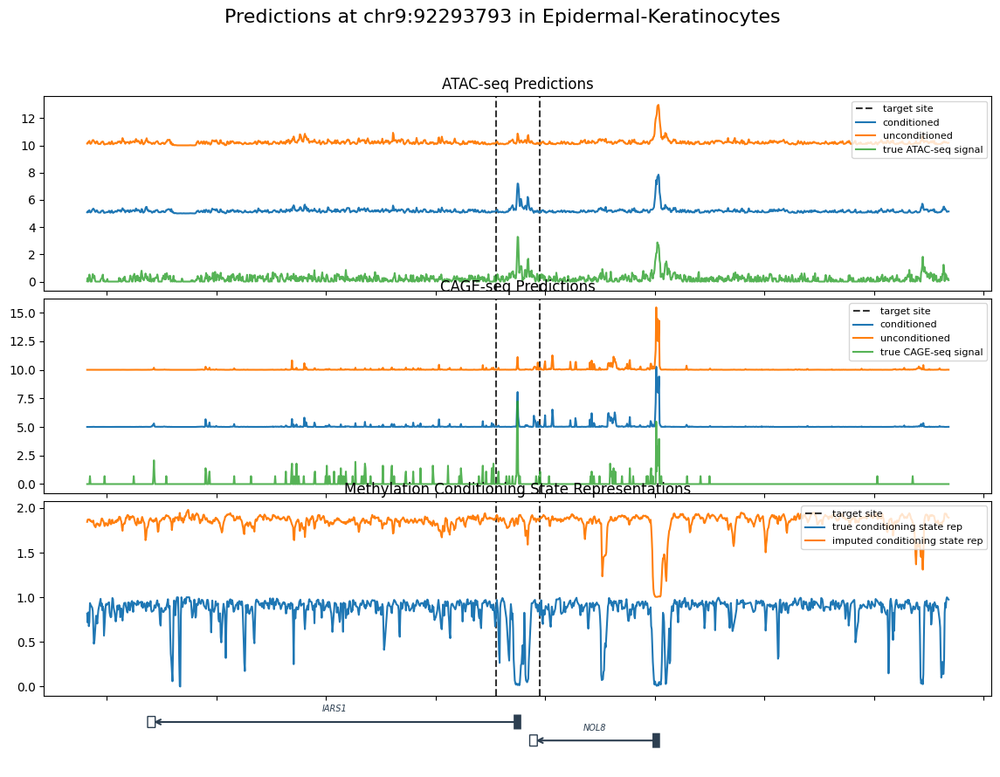

Skipping Epidermal-Keratinocytes at chr6:154344076 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


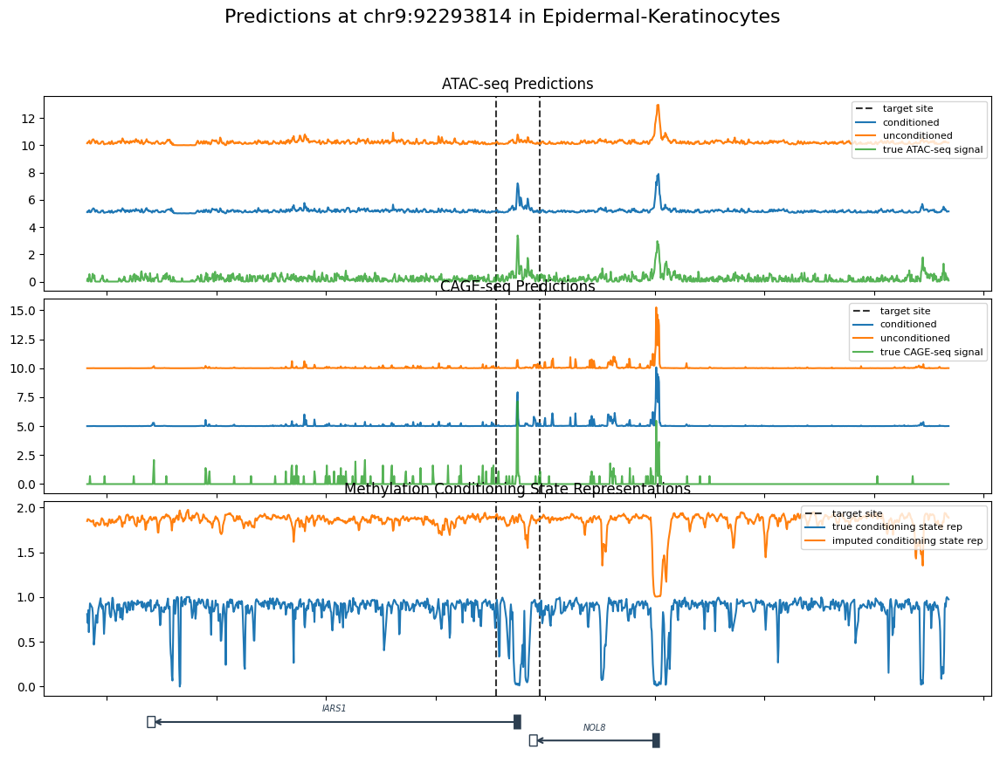

/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


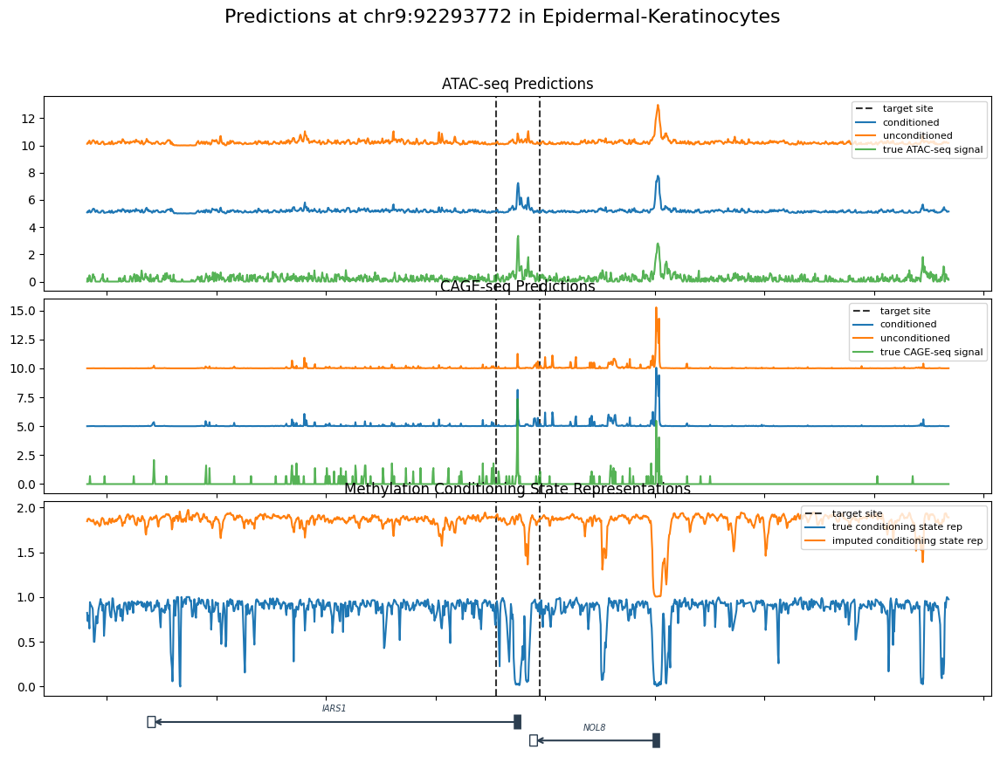

Skipping Epidermal-Keratinocytes at chr6:154344055 due to no TSS within 5000bp
Skipping Epidermal-Keratinocytes at chr19:4915010 due to no TSS within 5000bp
Skipping Epidermal-Keratinocytes at chr6:139539910 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


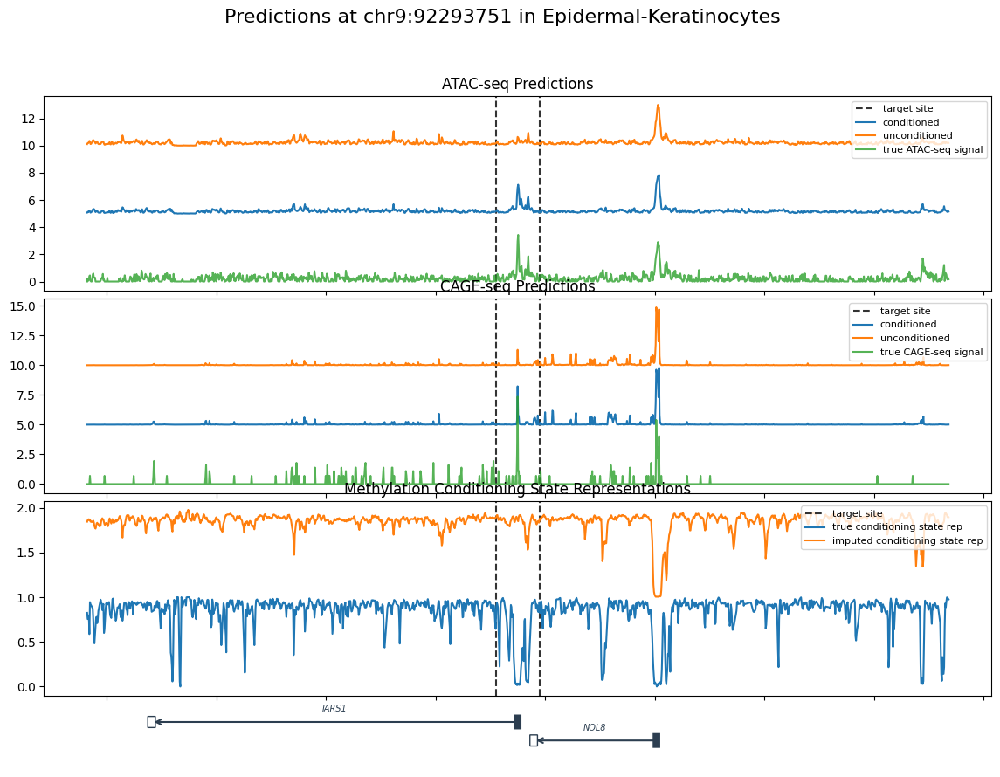

Skipping Colon-Left-Epithelial at chr7:72682968 due to no TSS within 5000bp
Skipping Colon-Left-Epithelial at chr6:106733583 due to no TSS within 5000bp
Skipping Colon-Left-Epithelial at chr6:106742287 due to no TSS within 5000bp
Skipping Colon-Left-Epithelial at chr6:106751631 due to no TSS within 5000bp
Skipping Colon-Left-Epithelial at chr6:168937961 due to no TSS within 5000bp
Skipping Colon-Left-Epithelial at chr7:74167567 due to no TSS within 5000bp
Skipping Colon-Left-Epithelial at chr8:30111528 due to no TSS within 5000bp
Skipping Colon-Left-Epithelial at chr6:147341607 due to no TSS within 5000bp
Skipping Colon-Left-Epithelial at chr6:121314626 due to no TSS within 5000bp
Skipping Colon-Left-Epithelial at chr8:40099086 due to no TSS within 5000bp
Skipping Colon-Left-Epithelial at chr8:40174862 due to no TSS within 5000bp
Skipping Colon-Left-Epithelial at chr6:150710373 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


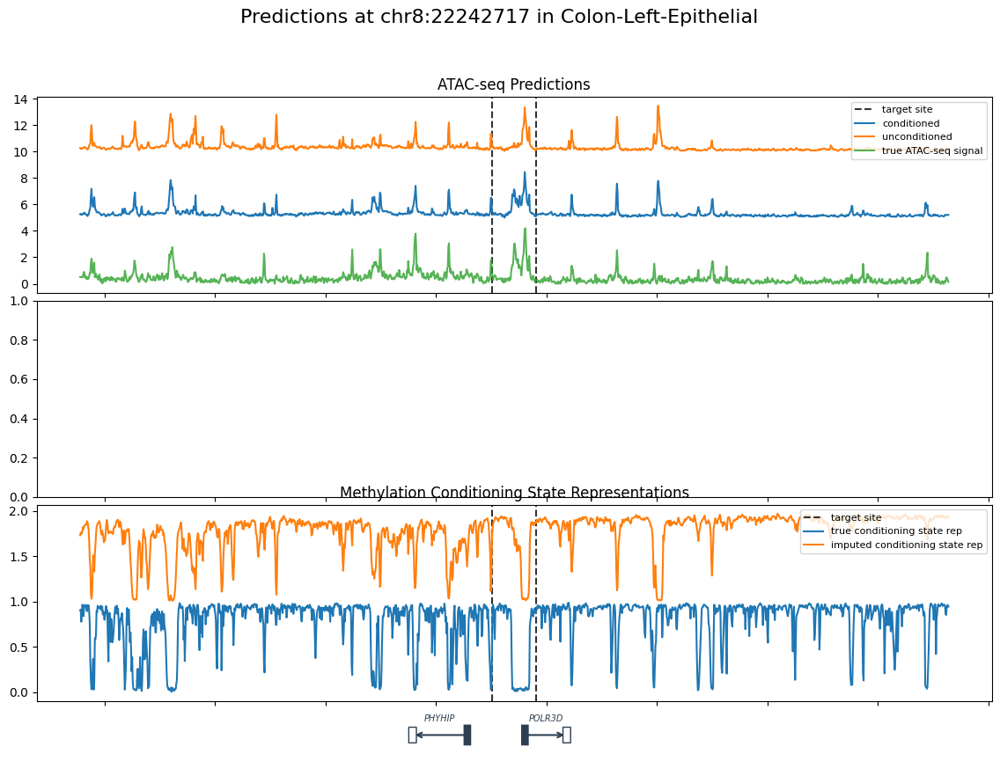

/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


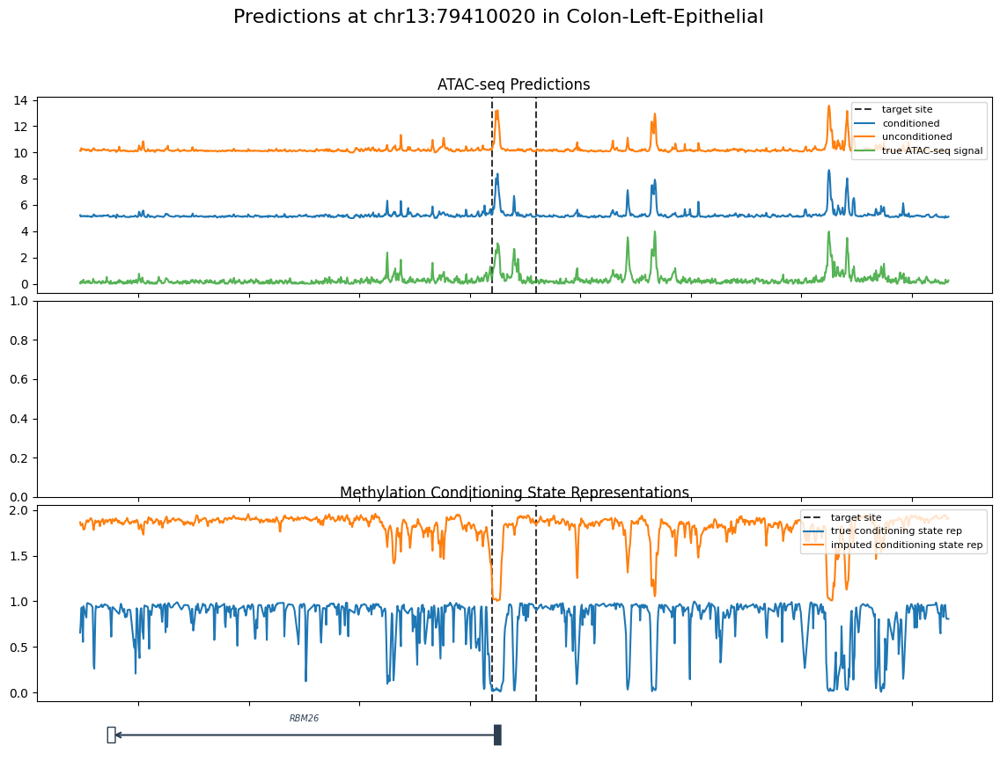

Skipping Colon-Left-Epithelial at chr5:16728109 due to no TSS within 5000bp
Skipping Colon-Left-Epithelial at chr9:117720693 due to no TSS within 5000bp
Skipping Colon-Left-Epithelial at chr9:117773173 due to no TSS within 5000bp
Skipping Colon-Left-Epithelial at chr6:147341628 due to no TSS within 5000bp
Skipping Colon-Left-Epithelial at chr9:92098211 due to no TSS within 5000bp
Skipping Colon-Left-Epithelial at chr6:150710459 due to no TSS within 5000bp
Skipping Colon-Left-Epithelial at chr9:87909972 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


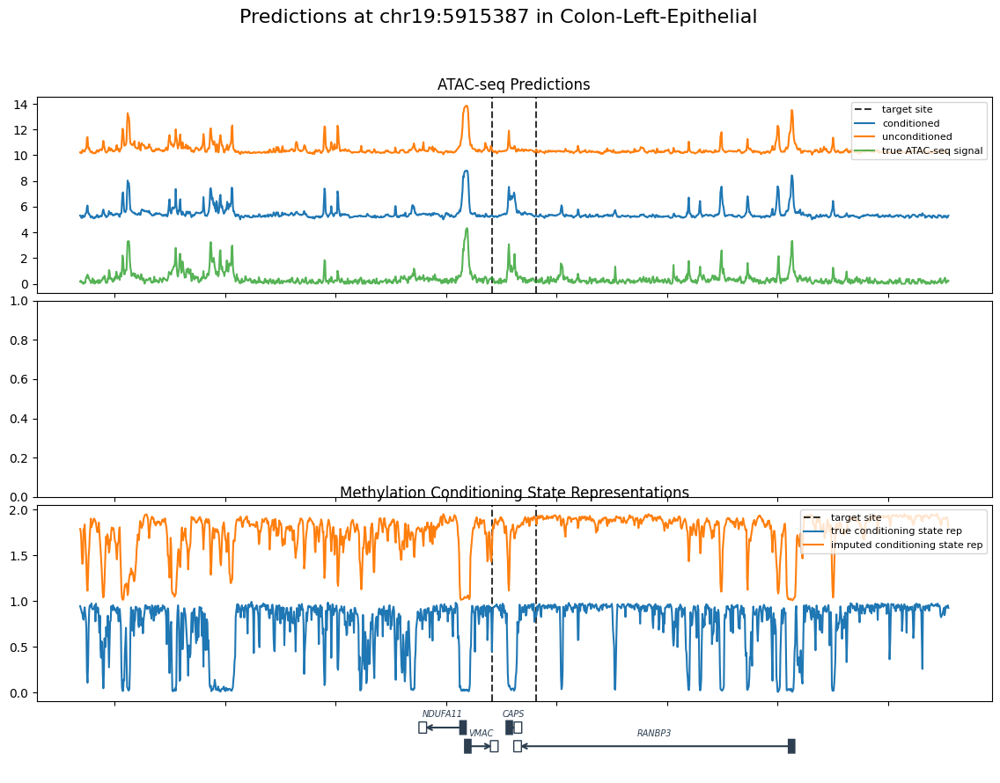

Skipping Colon-Left-Epithelial at chr6:136566192 due to no TSS within 5000bp
Skipping Colon-Left-Epithelial at chr6:160014459 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


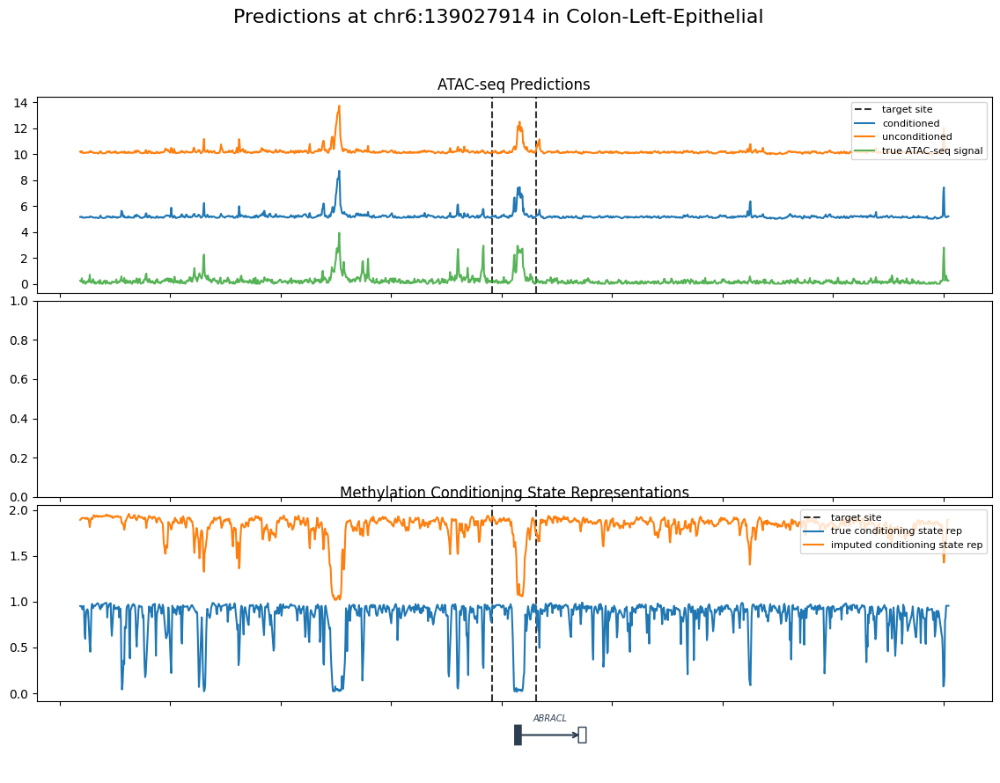

Skipping Colon-Left-Epithelial at chr6:122666147 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


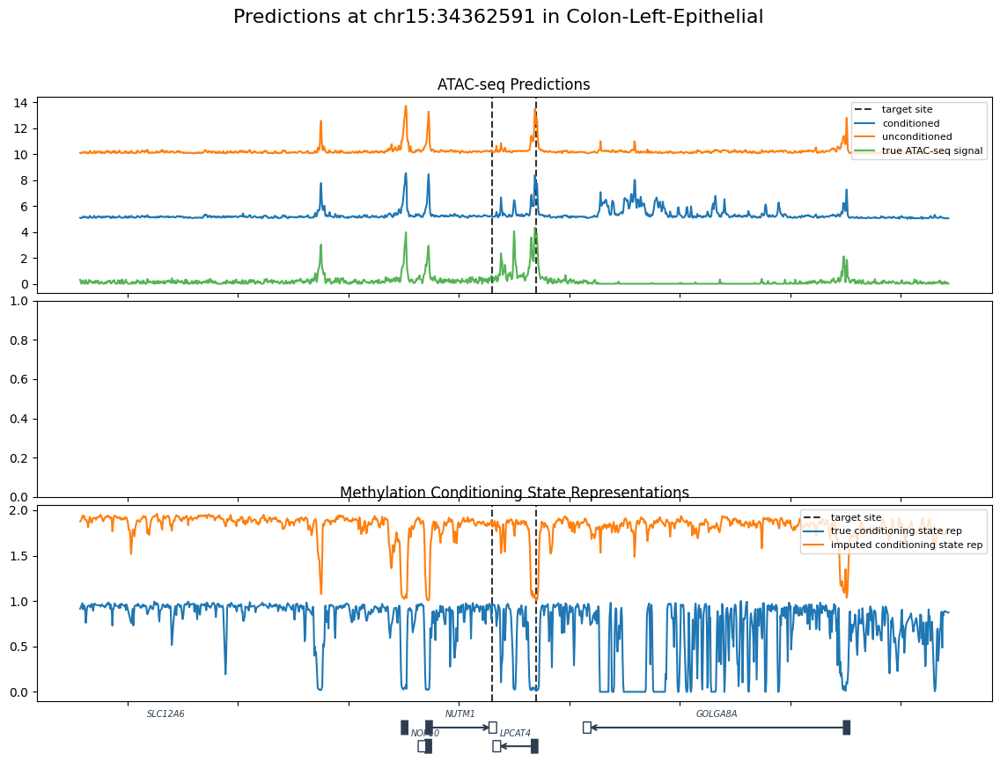

Skipping Colon-Left-Epithelial at chr6:167907120 due to no TSS within 5000bp
Skipping Colon-Left-Epithelial at chr8:40040164 due to no TSS within 5000bp
Skipping Colon-Left-Epithelial at chr5:33008988 due to no TSS within 5000bp


/tmp/ipykernel_1505328/3203697833.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


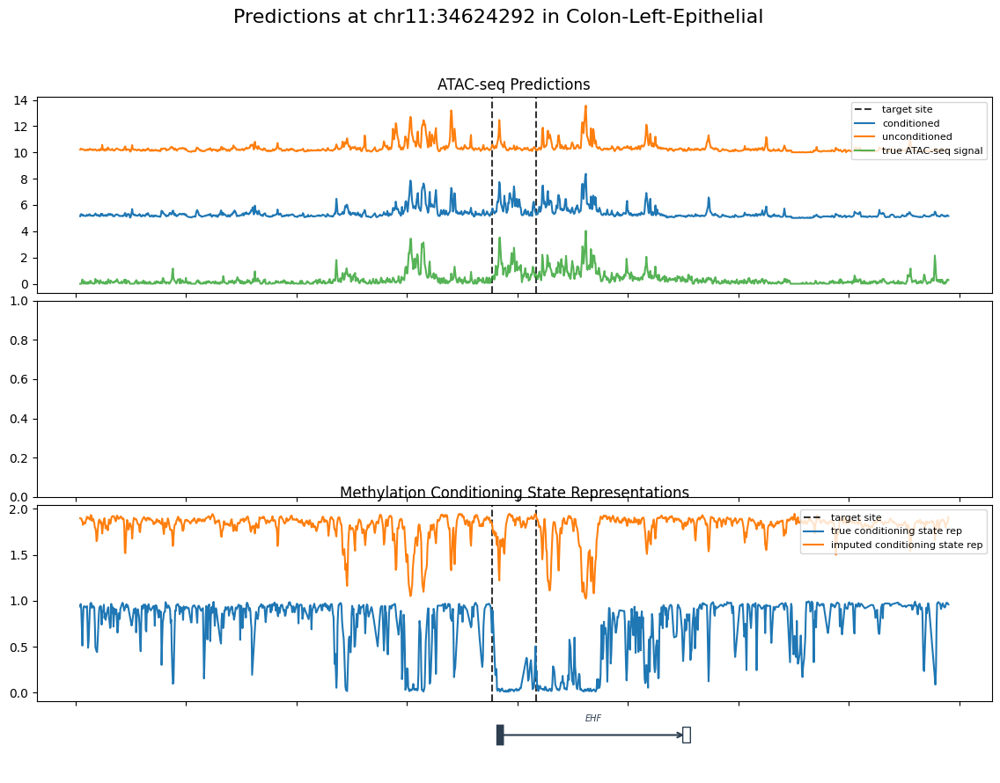

In [5]:
# cell_types_to_skip = {"Pancreas-Acinar","Adipocytes","Pancreas-Alpha"}
cell_types_to_skip = set(["Pancreas-Acinar", "Pancreas-Alpha", "Adipocytes", "Blood-B-Mem", "Lung-Alveolar-Epithel",
"Breast-Basal-Epithel", "Lung-Alveolar-Endothel", "Coronary-Artery-Smooth-Muscle", "Lung-Alveolar-Macrophages", "Pancreas-Beta",
"Lung-Bronchus-Epithel", "Heart-Cardiomyocyte", "Pancreas-Delta", "Pancreas-Duct", "Aorta" ])
cell_types_to_include = set()
# {"Liver-Hepatocytes",}
plt_range_from_site = 5000
skip_if_no_atac_or_cage = False
max_plots = 50
total_plots = 0
# with open("loci_with_big_model_improvements_cage_1.0k_samples.bed", "r") as f:
with open("loci_with_big_model_improvements_atac_all_samples.bed", "r") as f:
    for line in f:
        chrom, site, _, cell_type = line.strip().split()
        if cell_type in cell_types_to_skip:
            continue
        if len(cell_types_to_include)>0:
            if cell_type not in cell_types_to_include:
                continue
        cell_types = io_mappings_df[io_mappings_df["methylation_files"].str.contains(cell_type)]["absolute_cell_type"].to_list()
        atac_tasks = io_mappings_df[
            (io_mappings_df["methylation_files"].str.contains(cell_type))
            & (io_mappings_df["data_type"] == "ATAC-seq")
            ]["absolute_channel"].to_list()
        cage_tasks = io_mappings_df[
            (io_mappings_df["methylation_files"].str.contains(cell_type))
            & (io_mappings_df["data_type"] == "CAGE-seq")
            ]["absolute_channel"].to_list()
        atac_files_list = io_mappings_df[
            (io_mappings_df["methylation_files"].str.contains(cell_type))
            & (io_mappings_df["data_type"] == "ATAC-seq")
        ]["label_files"].to_list()
        if len(atac_files_list) > 0:
            search_term = atac_files_list[0].strip("'[]").split(", ")[0].replace(' ','%20').strip("'")
            atac_files = [
                f for f in (atac_atlas / "bigwigs").glob(f"*{search_term}*.bw")
                if not f.name.startswith("Fetal")
            ]
            if len(atac_files) == 0:
                print(f"No ATAC-seq files found for {cell_type} with search term {search_term}")
            else:
                atac_targets = conditioned_predictor.load_targets(
                    chromosome=chrom,
                    start=int(site) - 524288//2,
                    end=int(site) + 524288//2,
                    target_paths=atac_files,
                )
        else:
            atac_targets = None
        cage_files_list = io_mappings_df[
            (io_mappings_df["methylation_files"].str.contains(cell_type))
            & (io_mappings_df["data_type"] == "CAGE-seq")
        ]["label_files"].to_list()
        if len(cage_files_list)>0:
            search_term = cage_files_list[0].strip("'[]").split(", ")[0].strip("'")
            cage_files = list((cage_atlas / "hg38_v9").glob(f"*{search_term}*hg38.nobarcode.ctss.sorted.bed.gz"))
            if len(list(cage_files)) == 0:
                print(f"No CAGE-seq files found for {cell_type} with search term {search_term}")
            cage_targets = conditioned_predictor.load_targets(
                chromosome=chrom,
                start=int(site) - 524288//2,
                end=int(site) + 524288//2,
                target_paths=cage_files,
            )
        else:
            cage_targets = None
        # print(f"slice into atac_targets: {slice(atac_targets.shape[-1]//2-20,atac_targets.shape[-1]//2+20)}")
        # atac_targets_mean = atac_targets[
        #         ...,
        #         atac_targets.shape[-1]//2-20:atac_targets.shape[-1]//2+20
        #     ].mean()
        # if atac_targets is None or atac_targets_mean>0.1:
        #     print(f"skipping because mean is {atac_targets_mean} which is too high")
        #     continue
        # else:
        #     print(f"keeping because mean is {atac_targets_mean} which is ok")
        if skip_if_no_atac_or_cage and (atac_targets is None or cage_targets is None):
            print(f"Skipping {cell_type} at {chrom}:{site} due to missing ATAC-seq or CAGE-seq data")
            continue
        site = int(site)
        methylation_paths = list((methylation_atlas / "GSE186458_RAW").glob(f"*{cell_type}*hg38.bigwig"))
        tss_in_range = fetch_tss_from_gtf(
            gtf_annotation,
            (chrom,site - 50_000//2,site + 50_000//2),
        )
        tss_within_plt_range = False
        for tss_dict in tss_in_range:
            if abs(tss_dict["tss"]-site)<plt_range_from_site:
                tss_within_plt_range = True
                break
        if not tss_within_plt_range:
            print(f"Skipping {cell_type} at {chrom}:{site} due to no TSS within {plt_range_from_site}bp")
            continue
        predictions_dict = conditioned_predictor.predict_locus(
            chromosome=chrom,
            start=site - 524288//2,
            end=site + 524288//2,
            sequence_path = genomes / "hg38.fa",
            methylation_paths = methylation_paths,
        )
        unconditioned_predictions_dict = unconditioned_predictor.predict_locus(
            chromosome=chrom,
            start=site - 524288//2,
            end=site + 524288//2,
            sequence_path = genomes / "hg38.fa",
            methylation_paths = methylation_paths,
        )
        total_plots+=1
        fig, (ax_atac, ax_cage, ax_methylation, ax_genes) = plt.subplots(
            4, 1, figsize=(14, 10), sharex=True,
            gridspec_kw={'height_ratios': [3, 3, 3, 1], 'hspace': 0.05}
        )

        fig.suptitle(f"Predictions at {chrom}:{site} in {cell_type}", fontsize=16)
        if len(atac_tasks)>0:
            ax_atac.axvline(site-plt_range_from_site, color='black', linestyle='--', label="target site", alpha=0.8)
            ax_atac.axvline(site+plt_range_from_site, color='black', linestyle='--', alpha=0.8)
            # ax_atac.axhline(0, color="black")
            # ax_atac.axhline(10, color="black")
            # ax_atac.axhline(20, color="black")
            ax_atac.plot(predictions_dict["output_coordinates"],
                        np.log1p(predictions_dict["predictions"][0, atac_tasks, :].mean(0))+5,
                        label="conditioned", alpha=1)
            ax_atac.plot(unconditioned_predictions_dict["output_coordinates"],
                        np.log1p(unconditioned_predictions_dict["predictions"][0, atac_tasks, :].mean(0))+10,
                        label="unconditioned", alpha=1)
            if atac_targets is not None:
                ax_atac.plot(predictions_dict["output_coordinates"],np.log1p(atac_targets.squeeze()), label="true ATAC-seq signal", alpha=0.8)
            ax_atac.set_title("ATAC-seq Predictions", fontsize=12)
            ax_atac.legend(loc='upper right', fontsize=8)
        if len(cage_tasks)>0:
            ax_cage.axvline(site+plt_range_from_site, color='black', linestyle='--', label="target site", alpha=0.8)
            ax_cage.axvline(site-plt_range_from_site, color='black', linestyle='--', alpha=0.8)
            # ax_cage.axhline(0, color="black")
            # ax_cage.axhline(10, color="black")
            # ax_cage.axhline(20, color="black")
            ax_cage.plot(predictions_dict["output_coordinates"],
                        np.log1p(predictions_dict["predictions"][0, cage_tasks, :].mean(0))+5,
                        label="conditioned", alpha=1)
            ax_cage.plot(unconditioned_predictions_dict["output_coordinates"],
                        np.log1p(unconditioned_predictions_dict["predictions"][0, cage_tasks, :].mean(0))+10,
                        label="unconditioned", alpha=1)
            if cage_targets is not None:
                ax_cage.plot(predictions_dict["output_coordinates"],np.log1p(128*cage_targets.squeeze()), label="true CAGE-seq signal", alpha=0.8)
            ax_cage.set_title("CAGE-seq Predictions", fontsize=12)
            ax_cage.legend(loc='upper right', fontsize=8)
        ax_methylation.axvline(site-plt_range_from_site, color='black', linestyle='--', label="target site", alpha=0.8)
        ax_methylation.axvline(site+plt_range_from_site, color='black', linestyle='--', alpha=0.8)
        ax_methylation.plot(predictions_dict["output_coordinates"].squeeze(),
                    predictions_dict["true_conditioning_state_rep"][0, 0, :].squeeze(),
                    label="true conditioning state rep", alpha=1)
        ax_methylation.plot(unconditioned_predictions_dict["output_coordinates"].squeeze(),
                    predictions_dict["imputed_conditioning_state_rep"][0, cell_types, :].mean(0).squeeze()+1,
                    label="imputed conditioning state rep", alpha=1)
        ax_methylation.set_title("Methylation Conditioning State Representations", fontsize=12)
        ax_methylation.legend(loc='upper right', fontsize=8)

        add_gene_annotations(ax_genes, tss_in_range, xlim=ax_atac.get_xlim())
        fig.tight_layout()
        plt.show()
        if total_plots>=max_plots:
            break